# Study 1: Annotation Consistency Analysis

**Research framework:** Both human and LLM outputs are imperfect, context-sensistive interpreters (Törnberg, 2024). Reliability is assessed through stability, consistency, and sensitivity rather than deviation from an assumed human gold standard.

| Section | Focus | Metrics |
|---|---|---|
| A | Intra-annotator reliability | Temporal κ, Spearman ρ, MAD, signed drift |
| B | Inter-annotator agreement | Pairwise κ, Krippendorff α, Spearman ρ |
| C | Distributional analysis | Extreme value clustering, score distributions |

**Models:** GPT-4o (frontier), Claude Sonnet (mid-tier, constitutional AI), Llama 3.1-8B (small open-weight)

## 0. Configuration

In [4]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import krippendorff
from scipy.stats import spearmanr, chi2_contingency
from sklearn.metrics import cohen_kappa_score
from itertools import combinations

warnings.filterwarnings("ignore")

In [5]:
# File paths
INPUT_H1   = "annotations/human_phase1.csv"
INPUT_H2   = "annotations/human_phase2.csv"
INPUT_LLM  = "annotations/llm_annotations.csv"
OUTPUT_DIR = "study1"
FIGURE_DIR = os.path.join(OUTPUT_DIR, "figures")

SCORE_COLS   = [f"V{i}" for i in range(1, 9)]
VALID_SCORES = [1, 2, 3]

# Model display names (must match llm_name_version strings in CSV)
LLM_DISPLAY = {
    "gpt-4o-2024-08-06":                            "GPT-4o",
    "claude-sonnet-4-6":                            "Claude Sonnet",
    "meta-llama/Meta-Llama-3.1-8B-Instruct-Turbo": "Llama 3.1-8B",
}

os.makedirs(FIGURE_DIR, exist_ok=True)
print("Configuration loaded.")
print(f"  Output dir : {OUTPUT_DIR}")
print(f"  Figure dir : {FIGURE_DIR}")

Configuration loaded.
  Output dir : study1
  Figure dir : study1/figures


In [6]:
print(os.getcwd())

/Users/mariameshi/Documents/year_5/Thesis/Code/LLM_annotations


## 1. Load & Validate Data

In [7]:
def load_and_validate(path: str, label: str) -> pd.DataFrame:
    """Load CSV; report and drop rows with out-of-range scores."""
    df = pd.read_csv(path)
    missing = [c for c in ["tweet_id"] + SCORE_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"[{label}] Missing columns: {missing}")
    dropped_ids = set()
    for col in SCORE_COLS:
        invalid = df[~df[col].isin(VALID_SCORES)]
        if len(invalid):
            ids = invalid["tweet_id"].tolist()
            dropped_ids.update(ids)
            print(f"  WARNING [{label}] {len(invalid)} invalid scores in {col}:")
            print(f"    tweet_id(s) : {ids}")
            print(f"    raw value(s): {invalid[col].tolist()}")
            df = df[df[col].isin(VALID_SCORES)]
    if dropped_ids:
        print(f"  DROPPED {len(dropped_ids)} row(s) total: {sorted(dropped_ids)}")
    df["tweet_id"] = df["tweet_id"].astype(str)
    print(f"  Loaded [{label}]: {len(df)} rows")
    return df


h1  = load_and_validate(INPUT_H1, "Human Phase 1")
h2  = load_and_validate(INPUT_H2, "Human Phase 2")
llm = pd.read_csv(INPUT_LLM)
llm["tweet_id"] = llm["tweet_id"].astype(str)
print(f"  Loaded [LLM annotations]: {len(llm)} rows "
      f"across {llm['llm_name_version'].nunique()} models")
print(f"  Models present: {llm['llm_name_version'].unique().tolist()}")

  WARNING [Human Phase 1] 7 invalid scores in V1:
    tweet_id(s) : [66, 211, 405, 406, 436, 437, 445]
    raw value(s): [nan, nan, nan, nan, nan, nan, nan]
  WARNING [Human Phase 1] 1 invalid scores in V2:
    tweet_id(s) : [434]
    raw value(s): [nan]
  WARNING [Human Phase 1] 1 invalid scores in V4:
    tweet_id(s) : [70]
    raw value(s): [11.0]
  WARNING [Human Phase 1] 1 invalid scores in V7:
    tweet_id(s) : [42]
    raw value(s): [nan]
  DROPPED 10 row(s) total: [42, 66, 70, 211, 405, 406, 434, 436, 437, 445]
  Loaded [Human Phase 1]: 291 rows
  Loaded [Human Phase 2]: 50 rows
  Loaded [LLM annotations]: 652 rows across 3 models
  Models present: ['gpt-4o-2024-08-06', 'meta-llama/Meta-Llama-3.1-8B-Instruct-Turbo', 'claude-sonnet-4-6']


## 2. Build the 50-Tweet Overlap Core

All reliability metrics are computed on this overlap only. The overlap is defined by tweets present in Phase 2 (the re-annotation set).

In [8]:
overlap_ids = set(h2["tweet_id"])
h1_overlap  = h1[h1["tweet_id"].isin(overlap_ids)].copy()

print(f"Overlap size: {len(overlap_ids)} tweets")

missing_in_h1  = overlap_ids - set(h1["tweet_id"])
missing_in_llm = overlap_ids - set(llm["tweet_id"])
if missing_in_h1:
    print(f"  WARNING: {len(missing_in_h1)} Phase 2 tweets not found in Phase 1")
if missing_in_llm:
    print(f"  WARNING: {len(missing_in_llm)} Phase 2 tweets not found in LLM file")

Overlap size: 50 tweets


### 2a. Representativeness Check

Confirms the randomly drawn 50-tweet subset does not differ systematically from the full 300-tweet dataset on post-type composition or per-variable score means. A max |Δ| < 0.15 across variables is the acceptance threshold.

In [9]:
if "post_type" in h1.columns:
    full_pt  = h1["post_type"].value_counts(normalize=True).rename("Full 300")
    sub_pt   = h1_overlap["post_type"].value_counts(normalize=True).rename("Subset 50")
    pt_table = pd.concat([full_pt, sub_pt], axis=1).fillna(0)
    print("Post-type distribution:")
    display(pt_table.round(3))
    ct = pd.crosstab(
        h1["tweet_id"].isin(overlap_ids).map({True: "Subset", False: "Remainder"}),
        h1["post_type"]
    )
    chi2, p, dof, _ = chi2_contingency(ct)
    print(f"  Chi-square: χ²={chi2:.3f}, df={dof}, p={p:.3f}")
    print("  Result:", "representative (p > .05)" if p > 0.05
          else "WARNING: differs on post-type (p < .05) — note as limitation")

mean_full   = h1[SCORE_COLS].mean().rename("Mean (300)")
mean_subset = h1_overlap[SCORE_COLS].mean().rename("Mean (50)")
mean_diff   = (mean_full - mean_subset).abs().rename("|Δ|")
rep_table   = pd.concat([mean_full, mean_subset, mean_diff], axis=1).round(3)
print("\nPer-variable mean comparison:")
display(rep_table)
max_diff = mean_diff.max()
print(f"  Max |Δ|: {max_diff:.3f}")
print("  Result:", "representative (max |Δ| < 0.15)" if max_diff < 0.15
      else "WARNING: notable mean difference — note in methods")
rep_table.to_csv(os.path.join(OUTPUT_DIR, "representativeness_check.csv"))

Post-type distribution:


,Full 300,Subset 50
post_type,,
reply,0.660,0.72
tweet,0.206,0.18
quote,0.134,0.10


  Chi-square: χ²=1.054, df=2, p=0.590
  Result: representative (p > .05)

Per-variable mean comparison:


,Mean (300),Mean (50),|Δ|
V1,1.883,1.96,0.077
V2,1.079,1.08,0.001
V3,1.058,1.02,0.038
V4,1.010,1.00,0.010
V5,1.326,1.38,0.054
V6,1.447,1.36,0.087
V7,1.151,1.16,0.009
V8,1.375,1.34,0.035


  Max |Δ|: 0.087
  Result: representative (max |Δ| < 0.15)


## 3. Build Aligned Annotation Matrices

In [10]:
def get_llm_scores(llm_df, model_version, ids):
    subset = llm_df[
        (llm_df["llm_name_version"] == model_version) &
        (llm_df["tweet_id"].isin(ids))
    ][["tweet_id"] + SCORE_COLS].copy()
    return subset.set_index("tweet_id")


h1_mat = h1_overlap.set_index("tweet_id")[SCORE_COLS]
h2_mat = h2.set_index("tweet_id")[SCORE_COLS]

llm_mats = {}
for model in llm["llm_name_version"].unique():
    display_name = LLM_DISPLAY.get(model, model)
    mat = get_llm_scores(llm, model, overlap_ids)
    if len(mat) > 0:
        llm_mats[display_name] = mat
        print(f"  LLM matrix [{display_name}]: {len(mat)} tweets")

# Align to common tweet index
common_ids = set(h1_mat.index) & set(h2_mat.index)
for mat in llm_mats.values():
    common_ids &= set(mat.index)
common_ids = sorted(common_ids)
print(f"\n  Fully aligned core: {len(common_ids)} tweets across all annotators")

h1_mat = h1_mat.loc[common_ids]
h2_mat = h2_mat.loc[common_ids]
for k in llm_mats:
    llm_mats[k] = llm_mats[k].loc[common_ids]

  LLM matrix [GPT-4o]: 50 tweets
  LLM matrix [Llama 3.1-8B]: 50 tweets
  LLM matrix [Claude Sonnet]: 50 tweets

  Fully aligned core: 50 tweets across all annotators


In [45]:
# Remove legacy Claude Haiku rows (replaced by Claude Sonnet)
HAIKU_STRING = "claude-haiku-4-5-20251001"
if HAIKU_STRING in llm_mats:
    del llm_mats[HAIKU_STRING]
    print(f"  Removed '{HAIKU_STRING}' from llm_mats")

# Annotator registry
annotators = {"Human P1": h1_mat, "Human P2": h2_mat, **llm_mats}
print(f"  Annotators registered: {list(annotators.keys())}")

PALETTE = {
    "Human P1":      "#12436D",
    "Human P2":      "#28A197",
    "GPT-4o":        "#801650",
    "Claude Sonnet": "#F46A25",
    "Llama 3.1-8B":  "#A285D1",
}
ANNOTATOR_ORDER = [a for a in PALETTE if a in annotators]
print(f"  ANNOTATOR_ORDER: {ANNOTATOR_ORDER}")

  Annotators registered: ['Human P1', 'Human P2', 'GPT-4o', 'Llama 3.1-8B', 'Claude Sonnet']
  ANNOTATOR_ORDER: ['Human P1', 'Human P2', 'GPT-4o', 'Claude Sonnet', 'Llama 3.1-8B']


## 4. Helper Functions

In [12]:
def cohens_kappa(a, b):
    """Linear-weighted Cohen's κ for two ordinal arrays."""
    try:
        return cohen_kappa_score(a, b, weights="linear")
    except Exception:
        return np.nan


def krippendorff_alpha(matrices, variable):
    """Krippendorff's α (ordinal) across a list of score DataFrames."""
    try:
        data = np.array([m[variable].values for m in matrices], dtype=float)
        return krippendorff.alpha(
            reliability_data=data, level_of_measurement="ordinal"
        )
    except Exception:
        return np.nan


def spearman_rho(a, b):
    """Spearman ρ and p-value."""
    try:
        return spearmanr(a, b)
    except Exception:
        return (np.nan, np.nan)


def mean_abs_deviation(a, b):
    return float(np.mean(np.abs(a - b)))


print("Helper functions defined.")

Helper functions defined.


## 5. Shared Design Constants & Plot Helpers

In [13]:
LOW_VARIANCE    = {"V2", "V3", "V4"}
BASE_RATE_LABEL = {
    "V2": "92% score 1",
    "V3": "98% score 1",
    "V4": "100% score 1",
}

THRESHOLD_LOW  = 0.67
THRESHOLD_HIGH = 0.80

VARIABLE_LABELS = {
    "V1": "V1\nPartisan\nAnimosity",
    "V2": "V2\nUndemocratic\nPractices",
    "V3": "V3\nPartisan\nViolence",
    "V4": "V4\nUndemocratic\nCandidates",
    "V5": "V5\nOpp. to\nBipartisanship",
    "V6": "V6\nSocial\nDistrust",
    "V7": "V7\nSocial\nDistance",
    "V8": "V8\nBiased Fact\nEvaluation",
}

plt.rcParams.update({
    "font.family":     "sans-serif",
    "font.sans-serif": ["Calibri", "Arial", "Helvetica"],
    "font.size":       8,
    "axes.titlesize":  9.5,
    "axes.labelsize":  8.5,
    "xtick.labelsize": 7.5,
    "ytick.labelsize": 7.5,
    "legend.fontsize": 7.5,
})


def apply_zone_bands(ax, y_min=-0.25, y_max=1.08):
    for y in np.arange(round(y_min, 1), y_max, 0.1):
        ax.axhline(y, color="#E2E8F0", linewidth=0.6, zorder=0)
    ax.axhspan(THRESHOLD_HIGH, y_max,         color="#DCFCE7", alpha=0.4, zorder=0)
    ax.axhspan(THRESHOLD_LOW, THRESHOLD_HIGH, color="#FEF9C3", alpha=0.4, zorder=0)
    ax.axhspan(y_min, THRESHOLD_LOW,          color="#FEE2E2", alpha=0.2, zorder=0)
    ax.axhline(0, color="#94A3B8", linewidth=0.9, linestyle="--", zorder=1)


def style_axes(ax):
    ax.spines[["top", "right", "bottom"]].set_visible(False)
    ax.spines["left"].set_color("#CBD5E1")
    ax.tick_params(axis="both", labelsize=9)


def save_fig(fig, stem):
    path = os.path.join(FIGURE_DIR, stem + ".png")
    fig.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"  Saved: {path}")

---
## Section A: Intra-Annotator Reliability (Human Ceiling)

Measures how consistently the human annotator applies the AAPA codebook across a one-week interval (Phase 1 → Phase 2). This establishes the **human reliability ceiling** against which LLM performance is contextualised.

If human consistency is imperfect (e.g. κ < 0.85), LLM performance is not evaluated as deviation from truth but as a comparative level of stability within the same subjective task (Törnberg, 2024).

**Metrics:** temporal Cohen's κ (obsolete, replaced by Alpha), Spearman ρ · MAD · signed drift

In [14]:
intra_records = []
for v in SCORE_COLS:
    a = h1_mat[v].values
    b = h2_mat[v].values

    kappa     = cohens_kappa(a, b)
    alpha     = krippendorff_alpha([h1_mat, h2_mat], v)
    rho, pval = spearman_rho(a, b)
    mad       = mean_abs_deviation(a, b)
    drift     = float(np.mean(a.astype(float) - b.astype(float)))
    pct_agree = float(np.mean(a == b))

    intra_records.append({
        "variable":           v,
        "kappa_linear":       round(kappa, 3),
        "krippendorff_alpha": round(alpha, 3) if not np.isnan(alpha) else np.nan,
        "spearman_rho":       round(rho, 3),
        "spearman_p":         round(pval, 4),
        "MAD":                round(mad, 3),
        "mean_drift_H1-H2":   round(drift, 3),
        "pct_exact_agree":    round(pct_agree, 3),
    })

intra_df = pd.DataFrame(intra_records).set_index("variable")
intra_df.to_csv(os.path.join(OUTPUT_DIR, "sectionA_intra_annotator.csv"))

### Table A1: Intra-Annotator (H1 vs H2)

In [15]:
display(intra_df[["MAD", "mean_drift_H1-H2", "pct_exact_agree"]].round(3))

,MAD,mean_drift_H1-H2,pct_exact_agree
variable,,,
V1,0.32,0.08,0.70
V2,0.10,0.06,0.90
V3,0.04,0.00,0.96
V4,0.00,0.00,1.00
V5,0.40,0.00,0.62
V6,0.38,-0.02,0.64
V7,0.46,-0.26,0.58
V8,0.44,-0.40,0.60


### Table A2: Spearman ρ; Intra-Annotator (H1 vs H2)

In [16]:
display(intra_df[["spearman_rho", "spearman_p"]].round(3))

,spearman_rho,spearman_p
variable,,
V1,0.700,0.000
V2,-0.042,0.772
V3,-0.020,0.888
V4,NaN,NaN
V5,0.351,0.012
V6,0.224,0.118
V7,0.033,0.822
V8,0.479,0.000


### Table A3: Krippendorff's α; Intra-Annotator (H1 vs H2)

In [17]:
display(intra_df[["krippendorff_alpha"]].round(3))

,krippendorff_alpha
variable,
V1,0.695
V2,-0.042
V3,-0.010
V4,NaN
V5,0.355
V6,0.229
V7,-0.026
V8,0.321


### Figure A1: Intra-Annotator Reliability; Cohen's κ Bar Chart (obsolete)

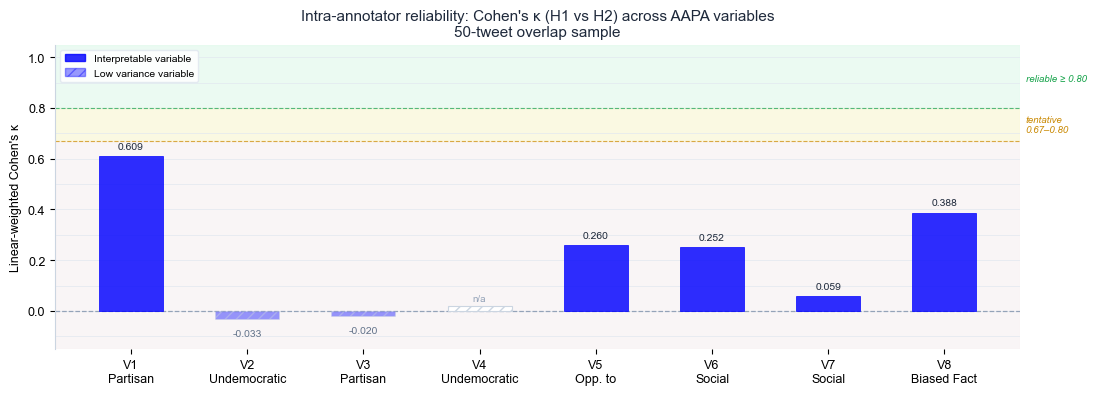

  Saved: study1/figures/figA1_intra_kappa_bars.png


In [18]:
kappa_vals = intra_df["kappa_linear"].values

fig, ax = plt.subplots(figsize=(11, 4))
ax.set_facecolor("#F8FAFC")
fig.patch.set_facecolor("white")

ax.axhspan(0.80, 1.05,  color="#DCFCE7", alpha=0.45, zorder=0)
ax.axhspan(0.67, 0.80,  color="#FEF9C3", alpha=0.45, zorder=0)
ax.axhspan(-0.15, 0.67, color="#FEE2E2", alpha=0.2,  zorder=0)
ax.axhline(0, color="#94A3B8", linewidth=0.9, linestyle="--", zorder=1)
for y in np.arange(-0.1, 1.05, 0.1):
    ax.axhline(y, color="#E2E8F0", linewidth=0.5, zorder=0)

colour = "blue"
for xi, (v, val) in enumerate(zip(SCORE_COLS, kappa_vals)):
    is_lv = v in LOW_VARIANCE
    if np.isnan(val):
        ax.bar(xi, 0.02, width=0.55, color="white", edgecolor="#CBD5E1",
               linewidth=0.8, hatch="///", zorder=2)
        ax.text(xi, 0.04, "n/a", ha="center", fontsize=7, color="#94A3B8")
        continue
    ax.bar(xi, val, width=0.55, color=colour,
           alpha=0.4 if is_lv else 0.82,
           hatch="///" if is_lv else "",
           edgecolor="#CBD5E1" if is_lv else colour,
           linewidth=0.6, zorder=2)
    label_y = val + 0.02 if val >= 0 else val - 0.04
    ax.text(xi, label_y, f"{val:.3f}", ha="center",
            va="bottom" if val >= 0 else "top", fontsize=7.5,
            color="#64748B" if is_lv else "#1E293B")

ax.axhline(0.80, color="#16A34A", linewidth=0.8, linestyle="--", alpha=0.7, zorder=1)
ax.axhline(0.67, color="#CA8A04", linewidth=0.8, linestyle="--", alpha=0.7, zorder=1)
ax.text(len(SCORE_COLS) - 0.3, 0.915, "reliable ≥ 0.80",
        fontsize=7, color="#16A34A", va="center", style="italic")
ax.text(len(SCORE_COLS) - 0.3, 0.735, "tentative\n0.67–0.80",
        fontsize=7, color="#CA8A04", va="center", style="italic")

ax.set_ylim(-0.15, 1.05)
ax.set_ylabel("Linear-weighted Cohen's κ", fontsize=9)
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
ax.set_xticks(range(len(SCORE_COLS)))
ax.set_xticklabels(
    [f"{v}\n{VARIABLE_LABELS[v].split(chr(10))[1]}" for v in SCORE_COLS],
    fontsize=8, multialignment="center"
)
style_axes(ax)
handles = [
    mpatches.Patch(color=colour, alpha=0.82, label="Interpretable variable"),
    mpatches.Patch(color=colour, alpha=0.4, hatch="///",
                   edgecolor="#CBD5E1", label="Low variance variable"),
]
ax.legend(handles=handles, fontsize=7.5, loc="upper left", framealpha=0.9, edgecolor="#E2E8F0")
ax.set_title("Intra-annotator reliability: Cohen's κ (H1 vs H2) across AAPA variables\n50-tweet overlap sample",
             fontsize=11, color="#1E293B")
plt.tight_layout()
save_fig(fig, "figA1_intra_kappa_bars")

### Figure A2: Intra-Annotator Reliability; Spearman ρ Bar Chart

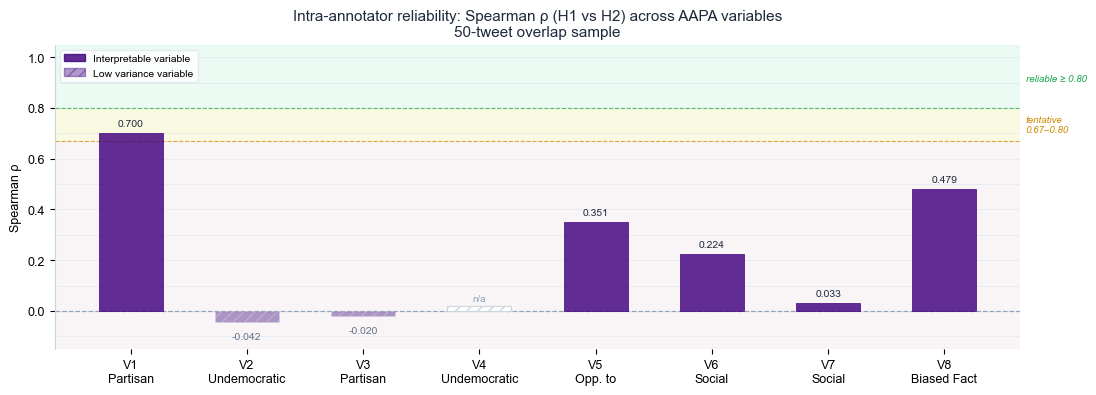

  Saved: study1/figures/figA2_intra_spearman_bars.png


In [41]:
rho_vals = intra_df["spearman_rho"].values

fig, ax = plt.subplots(figsize=(11, 4))
ax.set_facecolor("#F8FAFC")
fig.patch.set_facecolor("white")

ax.axhspan(0.80, 1.05,  color="#DCFCE7", alpha=0.45, zorder=0)
ax.axhspan(0.67, 0.80,  color="#FEF9C3", alpha=0.45, zorder=0)
ax.axhspan(-0.15, 0.67, color="#FEE2E2", alpha=0.2,  zorder=0)
ax.axhline(0, color="#94A3B8", linewidth=0.9, linestyle="--", zorder=1)
for y in np.arange(-0.1, 1.05, 0.1):
    ax.axhline(y, color="#E2E8F0", linewidth=0.5, zorder=0)

colour = "#3F007D"
for xi, (v, val) in enumerate(zip(SCORE_COLS, rho_vals)):
    is_lv = v in LOW_VARIANCE
    if np.isnan(val):
        ax.bar(xi, 0.02, width=0.55, color="white", edgecolor="#CBD5E1",
               linewidth=0.8, hatch="///", zorder=2)
        ax.text(xi, 0.04, "n/a", ha="center", fontsize=7, color="#94A3B8")
        continue
    ax.bar(xi, val, width=0.55, color=colour,
           alpha=0.4 if is_lv else 0.82,
           hatch="///" if is_lv else "",
           edgecolor="#CBD5E1" if is_lv else colour,
           linewidth=0.6, zorder=2)
    label_y = val + 0.02 if val >= 0 else val - 0.04
    ax.text(xi, label_y, f"{val:.3f}", ha="center",
            va="bottom" if val >= 0 else "top", fontsize=7.5,
            color="#64748B" if is_lv else "#1E293B")

ax.axhline(0.80, color="#16A34A", linewidth=0.8, linestyle="--", alpha=0.7, zorder=1)
ax.axhline(0.67, color="#CA8A04", linewidth=0.8, linestyle="--", alpha=0.7, zorder=1)
ax.text(len(SCORE_COLS) - 0.3, 0.915, "reliable ≥ 0.80",
        fontsize=7, color="#16A34A", va="center", style="italic")
ax.text(len(SCORE_COLS) - 0.3, 0.735, "tentative\n0.67–0.80",
        fontsize=7, color="#CA8A04", va="center", style="italic")

ax.set_ylim(-0.15, 1.05)
ax.set_ylabel("Spearman ρ", fontsize=9)
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
ax.set_xticks(range(len(SCORE_COLS)))
ax.set_xticklabels(
    [f"{v}\n{VARIABLE_LABELS[v].split(chr(10))[1]}" for v in SCORE_COLS],
    fontsize=8, multialignment="center"
)
style_axes(ax)
handles = [
    mpatches.Patch(color=colour, alpha=0.82, label="Interpretable variable"),
    mpatches.Patch(color=colour, alpha=0.4, hatch="///",
                   edgecolor="#CBD5E1", label="Low variance variable"),
]
ax.legend(handles=handles, fontsize=7.5, loc="upper left", framealpha=0.9, edgecolor="#E2E8F0")
ax.set_title("Intra-annotator reliability: Spearman ρ (H1 vs H2) across AAPA variables\n50-tweet overlap sample",
             fontsize=11, color="#1E293B")
plt.tight_layout()
save_fig(fig, "figA2_intra_spearman_bars")

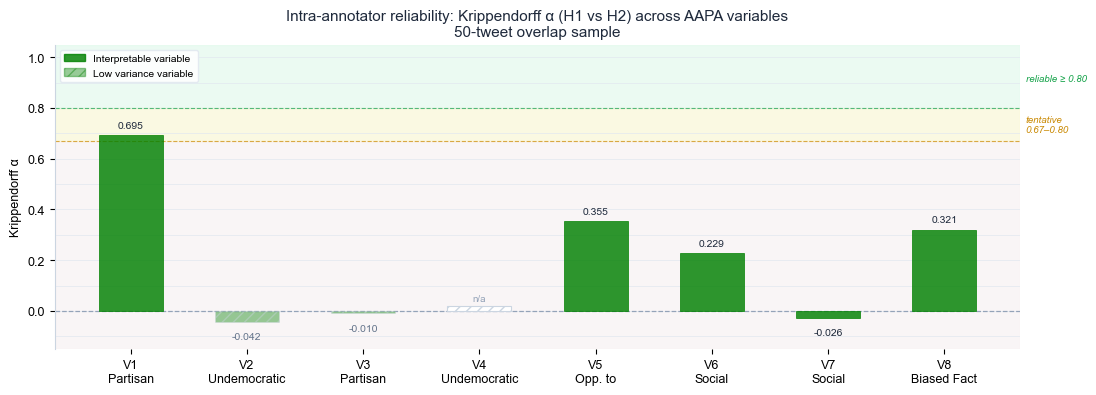

  Saved: study1/figures/figA3_intra_krippendorff_bars.png


In [20]:
alpha_vals = intra_df["krippendorff_alpha"].values

fig, ax = plt.subplots(figsize=(11, 4))
ax.set_facecolor("#F8FAFC")
fig.patch.set_facecolor("white")

ax.axhspan(0.80, 1.05,  color="#DCFCE7", alpha=0.45, zorder=0)
ax.axhspan(0.67, 0.80,  color="#FEF9C3", alpha=0.45, zorder=0)
ax.axhspan(-0.15, 0.67, color="#FEE2E2", alpha=0.2,  zorder=0)
ax.axhline(0, color="#94A3B8", linewidth=0.9, linestyle="--", zorder=1)
for y in np.arange(-0.1, 1.05, 0.1):
    ax.axhline(y, color="#E2E8F0", linewidth=0.5, zorder=0)

colour = "green"
for xi, (v, val) in enumerate(zip(SCORE_COLS, alpha_vals)):
    is_lv = v in LOW_VARIANCE
    if np.isnan(val):
        ax.bar(xi, 0.02, width=0.55, color="white", edgecolor="#CBD5E1",
               linewidth=0.8, hatch="///", zorder=2)
        ax.text(xi, 0.04, "n/a", ha="center", fontsize=7, color="#94A3B8")
        continue
    ax.bar(xi, val, width=0.55, color=colour,
           alpha=0.4 if is_lv else 0.82,
           hatch="///" if is_lv else "",
           edgecolor="#CBD5E1" if is_lv else colour,
           linewidth=0.6, zorder=2)
    label_y = val + 0.02 if val >= 0 else val - 0.04
    ax.text(xi, label_y, f"{val:.3f}", ha="center",
            va="bottom" if val >= 0 else "top", fontsize=7.5,
            color="#64748B" if is_lv else "#1E293B")

ax.axhline(0.80, color="#16A34A", linewidth=0.8, linestyle="--", alpha=0.7, zorder=1)
ax.axhline(0.67, color="#CA8A04", linewidth=0.8, linestyle="--", alpha=0.7, zorder=1)
ax.text(len(SCORE_COLS) - 0.3, 0.915, "reliable ≥ 0.80",
        fontsize=7, color="#16A34A", va="center", style="italic")
ax.text(len(SCORE_COLS) - 0.3, 0.735, "tentative\n0.67–0.80",
        fontsize=7, color="#CA8A04", va="center", style="italic")

ax.set_ylim(-0.15, 1.05)
ax.set_ylabel("Krippendorff α", fontsize=9)
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
ax.set_xticks(range(len(SCORE_COLS)))
ax.set_xticklabels(
    [f"{v}\n{VARIABLE_LABELS[v].split(chr(10))[1]}" for v in SCORE_COLS],
    fontsize=8, multialignment="center"
)
style_axes(ax)
handles = [
    mpatches.Patch(color=colour, alpha=0.82, label="Interpretable variable"),
    mpatches.Patch(color=colour, alpha=0.4, hatch="///",
                   edgecolor="#CBD5E1", label="Low variance variable"),
]
ax.legend(handles=handles, fontsize=7.5, loc="upper left", framealpha=0.9, edgecolor="#E2E8F0")
ax.set_title("Intra-annotator reliability: Krippendorff α (H1 vs H2) across AAPA variables\n50-tweet overlap sample",
             fontsize=11, color="#1E293B")
plt.tight_layout()
save_fig(fig, "figA3_intra_krippendorff_bars")

### A3: Session-Order Analysis (not enough data for this)

In [21]:
if "annotation_session" in h1.columns:
    h1_sess = h1_overlap[["tweet_id", "annotation_session"] + SCORE_COLS].copy()
    h1_sess["total_score"] = h1_sess[SCORE_COLS].sum(axis=1)
    session_summary = (
        h1_sess.groupby("annotation_session")["total_score"]
        .agg(["mean", "std", "count"])
        .reset_index()
    )
    session_summary.columns = ["session", "mean_total_score", "std_total_score", "n_tweets"]
    display(session_summary)
    session_summary.to_csv(
        os.path.join(OUTPUT_DIR, "sectionA_session_order.csv"), index=False
    )
else:
    print("No annotation_session column found in Phase 1 data.")

,session,mean_total_score,std_total_score,n_tweets
0,1,10.3,2.279008,50


---
## Section B: Inter-Annotator Agreement

Evaluates consensus between the human baseline and three LLM tiers. The key comparison is whether κ(H1 vs LLM) is meaningfully lower than κ(H1 vs H2). If it is not, the LLM is no less consistent with the human than the human is with themselves.

**Metrics:** pairwise Cohen's κ · Spearman ρ · MAD · Krippendorff's α

### B1. Compute Pairwise Metrics

In [22]:
human_labels = ["Human P1", "Human P2"]
llm_labels   = list(llm_mats.keys())

all_pairs = (
    [("Human P1", "Human P2")]
    + [(h, l) for h in human_labels for l in llm_labels]
    + list(combinations(llm_labels, 2))
)

inter_records = []
for label_a, label_b in all_pairs:
    mat_a = annotators[label_a]
    mat_b = annotators[label_b]
    for v in SCORE_COLS:
        a = mat_a[v].values
        b = mat_b[v].values
        kappa     = cohens_kappa(a, b)
        rho, pval = spearman_rho(a, b)
        mad       = mean_abs_deviation(a, b)
        inter_records.append({
            "annotator_A":  label_a,
            "annotator_B":  label_b,
            "pairing":      f"{label_a} vs {label_b}",
            "variable":     v,
            "kappa_linear": round(kappa, 3),
            "spearman_rho": round(rho, 3),
            "spearman_p":   round(pval, 4),
            "MAD":          round(mad, 3),
        })

inter_df = pd.DataFrame(inter_records)
inter_df.to_csv(os.path.join(OUTPUT_DIR, "sectionB_inter_annotator.csv"), index=False)
print(f"Computed {len(inter_df)} pairing × variable combinations")

Computed 80 pairing × variable combinations


### Table B1: Cohen's κ (Linear-Weighted); Inter-Annotator Pivot (obsolete)

In [23]:
kappa_pivot = inter_df.pivot_table(
    index="pairing", columns="variable", values="kappa_linear"
)[SCORE_COLS]
display(kappa_pivot.round(3))

variable,V1,V2,V3,V4,V5,V6,V7,V8
pairing,,,,,,,,
GPT-4o vs Claude Sonnet,0.652,0.280,0.000,0.380,0.563,0.525,0.521,0.308
GPT-4o vs Llama 3.1-8B,0.460,0.175,0.117,0.223,0.186,0.424,0.471,0.448
Human P1 vs Claude Sonnet,0.461,-0.126,0.000,0.000,0.355,0.301,0.005,0.142
Human P1 vs GPT-4o,0.324,0.018,-0.020,0.000,0.186,0.187,0.124,0.297
Human P1 vs Human P2,0.609,-0.033,-0.020,NaN,0.260,0.252,0.059,0.388
Human P1 vs Llama 3.1-8B,0.407,-0.078,-0.019,0.000,0.147,0.096,-0.119,0.124
Human P2 vs Claude Sonnet,0.510,0.088,0.000,0.000,0.594,0.367,0.496,0.226
Human P2 vs GPT-4o,0.514,0.135,-0.020,0.000,0.420,0.339,0.444,0.250
Human P2 vs Llama 3.1-8B,0.621,0.099,0.117,0.000,0.229,0.134,0.180,0.140


### Table B2: Spearman ρ; Inter-Annotator Pivot

In [24]:
rho_pivot = inter_df.pivot_table(
    index="pairing", columns="variable", values="spearman_rho"
)[SCORE_COLS]
display(rho_pivot.round(3))

variable,V1,V2,V3,V4,V5,V6,V7,V8
pairing,,,,,,,,
GPT-4o vs Claude Sonnet,0.793,0.316,NaN,0.489,0.581,0.687,0.808,0.654
GPT-4o vs Llama 3.1-8B,0.616,0.273,0.354,0.506,0.392,0.538,0.615,0.548
Human P1 vs Claude Sonnet,0.569,-0.183,NaN,NaN,0.387,0.336,-0.003,0.242
Human P1 vs GPT-4o,0.437,0.021,-0.020,NaN,0.208,0.266,0.177,0.342
Human P1 vs Human P2,0.700,-0.042,-0.020,NaN,0.351,0.224,0.033,0.479
Human P1 vs Llama 3.1-8B,0.472,-0.138,-0.058,NaN,0.163,0.071,-0.148,0.159
Human P2 vs Claude Sonnet,0.628,0.215,NaN,NaN,0.687,0.423,0.582,0.295
Human P2 vs GPT-4o,0.671,0.269,-0.020,NaN,0.475,0.406,0.540,0.288
Human P2 vs Llama 3.1-8B,0.694,0.319,0.354,NaN,0.379,0.178,0.295,0.107


### Table B3: MAD; Inter-Annotator Pivot

In [25]:
mad_pivot = inter_df.pivot_table(
    index="pairing", columns="variable", values="MAD"
)[SCORE_COLS]
display(mad_pivot.round(3))

variable,V1,V2,V3,V4,V5,V6,V7,V8
pairing,,,,,,,,
GPT-4o vs Claude Sonnet,0.26,0.30,0.02,0.06,0.24,0.30,0.32,0.58
GPT-4o vs Llama 3.1-8B,0.44,0.38,0.26,0.24,0.40,0.36,0.22,0.32
Human P1 vs Claude Sonnet,0.44,0.40,0.02,0.06,0.38,0.48,0.66,0.82
Human P1 vs GPT-4o,0.54,0.26,0.04,0.04,0.46,0.46,0.34,0.40
Human P1 vs Human P2,0.32,0.10,0.04,0.00,0.40,0.38,0.46,0.44
Human P1 vs Llama 3.1-8B,0.54,0.40,0.30,0.28,0.38,0.50,0.36,0.56
Human P2 vs Claude Sonnet,0.40,0.30,0.02,0.06,0.22,0.42,0.36,0.62
Human P2 vs GPT-4o,0.38,0.20,0.04,0.04,0.30,0.36,0.28,0.48
Human P2 vs Llama 3.1-8B,0.34,0.30,0.26,0.28,0.34,0.48,0.42,0.56


### B2. Krippendorff's α; Pairwise and Multi-Annotator Subsets

Primary global reliability measure. Conventional thresholds: α ≥ 0.80 reliable; α ≥ 0.67 tentative; α < 0.67 below threshold.

In [26]:
alpha_sets = {
    "All annotators":               list(annotators.values()),
    "Humans only (H1, H2)":         [h1_mat, h2_mat],
    "LLMs only (3 models)":         list(llm_mats.values()),
    "H1 + GPT-4o":                  [h1_mat, llm_mats.get("GPT-4o")],
    "H1 + Claude Sonnet":           [h1_mat, llm_mats.get("Claude Sonnet")],
    "H1 + Llama 3.1-8B":            [h1_mat, llm_mats.get("Llama 3.1-8B")],
    "H2 + GPT-4o":                  [h2_mat, llm_mats.get("GPT-4o")],
    "H2 + Claude Sonnet":           [h2_mat, llm_mats.get("Claude Sonnet")],
    "H2 + Llama 3.1-8B":            [h2_mat, llm_mats.get("Llama 3.1-8B")],
    "GPT-4o + Claude Sonnet":       [llm_mats.get("GPT-4o"), llm_mats.get("Claude Sonnet")],
    "GPT-4o + Llama 3.1-8B":        [llm_mats.get("GPT-4o"), llm_mats.get("Llama 3.1-8B")],
    "Claude Sonnet + Llama 3.1-8B": [llm_mats.get("Claude Sonnet"), llm_mats.get("Llama 3.1-8B")],
}

alpha_records = []
for label, matrices in alpha_sets.items():
    matrices = [m for m in matrices if m is not None]
    if len(matrices) < 2:
        continue
    row = {"annotator_set": label}
    for v in SCORE_COLS:
        row[v] = round(krippendorff_alpha(matrices, v), 3)
    alpha_records.append(row)

alpha_df = pd.DataFrame(alpha_records).set_index("annotator_set")
alpha_df.to_csv(os.path.join(OUTPUT_DIR, "sectionC_krippendorff_alpha.csv"))

### Table B4: Krippendorff's α; All Annotator Subsets

In [27]:
display(alpha_df.round(3))

,V1,V2,V3,V4,V5,V6,V7,V8
annotator_set,,,,,,,,
All annotators,0.596,0.158,0.065,0.192,0.360,0.353,0.340,0.305
"Humans only (H1, H2)",0.695,-0.042,-0.010,NaN,0.355,0.229,-0.026,0.321
LLMs only (3 models),0.661,0.410,0.077,0.405,0.338,0.552,0.561,0.484
H1 + GPT-4o,0.339,-0.009,-0.010,-0.010,0.205,0.229,0.139,0.306
H1 + Claude Sonnet,0.551,-0.206,0.000,-0.010,0.373,0.250,-0.073,-0.036
H1 + Llama 3.1-8B,0.442,-0.137,-0.076,-0.065,0.078,0.079,-0.137,0.080
H2 + GPT-4o,0.603,0.062,-0.010,-0.010,0.474,0.376,0.528,0.256
H2 + Claude Sonnet,0.628,-0.015,0.000,-0.010,0.676,0.350,0.570,0.232
H2 + Llama 3.1-8B,0.676,0.111,0.176,-0.065,0.213,0.185,0.218,0.110


---
## Section C: Distributional and Error Analysis

Identifies systematic patterns in annotation judgement beyond point estimates of agreement. Distinguishes random disagreement from threshold differences and capability-related scoring biases.

### C1. Score Drift (H1 → H2)

In [28]:
drift_rows = []
for tid in common_ids:
    row = {"tweet_id": tid}
    for v in SCORE_COLS:
        row[f"{v}_H1"]    = h1_mat.loc[tid, v]
        row[f"{v}_H2"]    = h2_mat.loc[tid, v]
        row[f"{v}_drift"] = int(h1_mat.loc[tid, v]) - int(h2_mat.loc[tid, v])
    drift_rows.append(row)

drift_df = pd.DataFrame(drift_rows)
drift_df.to_csv(os.path.join(OUTPUT_DIR, "score_drift.csv"), index=False)

print(f"{'Variable':<6} {'Mean drift':>12} {'Up':>6} {'Same':>6} {'Down':>6}")
print("-" * 40)
for v in SCORE_COLS:
    col  = f"{v}_drift"
    up   = (drift_df[col] > 0).sum()
    same = (drift_df[col] == 0).sum()
    down = (drift_df[col] < 0).sum()
    mean = drift_df[col].mean()
    print(f"{v:<6} {mean:>+12.3f} {up:>6} {same:>6} {down:>6}")

Variable   Mean drift     Up   Same   Down
----------------------------------------
V1           +0.080     10     35      5
V2           +0.060      4     45      1
V3           +0.000      1     48      1
V4           +0.000      0     50      0
V5           +0.000      9     31     10
V6           -0.020      8     32     10
V7           -0.260      5     29     16
V8           -0.400      1     30     19


### C2. Extreme Value Clustering

In [29]:
extreme_records = []
for label, mat in annotators.items():
    for v in SCORE_COLS:
        extreme_records.append({
            "annotator":  label,
            "variable":   v,
            "pct_score3": round((mat[v] == 3).mean(), 3),
            "pct_score1": round((mat[v] == 1).mean(), 3),
        })

extreme_df = pd.DataFrame(extreme_records)
extreme_df.to_csv(os.path.join(OUTPUT_DIR, "extreme_value_clusters.csv"), index=False)

ext_pivot = extreme_df.pivot_table(
    index="annotator", columns="variable", values="pct_score3"
)
print("Proportion of score = 3 per annotator × variable:")
display(ext_pivot.round(3))

Proportion of score = 3 per annotator × variable:


variable,V1,V2,V3,V4,V5,V6,V7,V8
annotator,,,,,,,,
Claude Sonnet,0.20,0.04,0.00,0.02,0.04,0.12,0.20,0.32
GPT-4o,0.08,0.00,0.00,0.00,0.02,0.02,0.00,0.02
Human P1,0.26,0.00,0.00,0.00,0.08,0.04,0.04,0.06
Human P2,0.24,0.00,0.00,0.00,0.02,0.02,0.06,0.12
Llama 3.1-8B,0.28,0.14,0.14,0.14,0.04,0.10,0.06,0.06


---
## Reliability Summary Table

In [30]:
def get_kappa(a, b, v):
    row = inter_df[
        (inter_df["annotator_A"].isin([a, b])) &
        (inter_df["annotator_B"].isin([a, b])) &
        (inter_df["variable"] == v)
    ]
    return row["kappa_linear"].values[0] if not row.empty else np.nan


def get_rho(a, b, v):
    row = inter_df[
        (inter_df["annotator_A"] == a) &
        (inter_df["annotator_B"] == b) &
        (inter_df["variable"] == v)
    ]
    return row["spearman_rho"].values[0] if not row.empty else np.nan


def get_alpha(label, v):
    row = alpha_df[alpha_df.index == label]
    return row[v].values[0] if not row.empty else np.nan


summary_rows = []
for v in SCORE_COLS:
    summary_rows.append({
        "Variable":             v,
        "κ (H1–H2)":            get_kappa("Human P1", "Human P2", v),
        "ρ (H1–H2)":            get_rho("Human P1", "Human P2", v),
        "MAD (H1–H2)":          intra_df.loc[v, "MAD"],
        "Drift (H1−H2)":        intra_df.loc[v, "mean_drift_H1-H2"],
        "κ (H1–GPT-4o)":        get_kappa("Human P1", "GPT-4o", v),
        "κ (H1–Claude Sonnet)": get_kappa("Human P1", "Claude Sonnet", v),
        "κ (H1–Llama 3.1-8B)":  get_kappa("Human P1", "Llama 3.1-8B", v),
        "α (all annotators)":   get_alpha("All annotators", v),
        "α (LLMs only)":        get_alpha("LLMs only (3 models)", v),
        "α (humans only)":      get_alpha("Humans only (H1, H2)", v),
    })

summary_df = pd.DataFrame(summary_rows).set_index("Variable").round(3)
summary_df.to_csv(os.path.join(OUTPUT_DIR, "reliability_summary.csv"))
display(summary_df)

,κ (H1–H2),ρ (H1–H2),MAD (H1–H2),Drift (H1−H2),κ (H1–GPT-4o),κ (H1–Claude Sonnet),κ (H1–Llama 3.1-8B),α (all annotators),α (LLMs only),α (humans only)
Variable,,,,,,,,,,
V1,0.609,0.700,0.32,0.08,0.324,0.461,0.407,0.596,0.661,0.695
V2,-0.033,-0.042,0.10,0.06,0.018,-0.126,-0.078,0.158,0.410,-0.042
V3,-0.020,-0.020,0.04,0.00,-0.020,0.000,-0.019,0.065,0.077,-0.010
V4,NaN,NaN,0.00,0.00,0.000,0.000,0.000,0.192,0.405,NaN
V5,0.260,0.351,0.40,0.00,0.186,0.355,0.147,0.360,0.338,0.355
V6,0.252,0.224,0.38,-0.02,0.187,0.301,0.096,0.353,0.552,0.229
V7,0.059,0.033,0.46,-0.26,0.124,0.005,-0.119,0.340,0.561,-0.026
V8,0.388,0.479,0.44,-0.40,0.297,0.142,0.124,0.305,0.484,0.321


---
## Visualisations

**Design language:**
- Green / yellow / red bands encode Krippendorff reliability zones (≥ 0.80, 0.67–0.80, < 0.67)
- Low-variance variables (V2, V3, V4) flagged with hatching and red labels
- Blues colourmap for κ/ρ matrices; Reds for Krippendorff; OrRd for extreme value clustering

### Figure 1: Krippendorff's α; Grouped Bar Chart

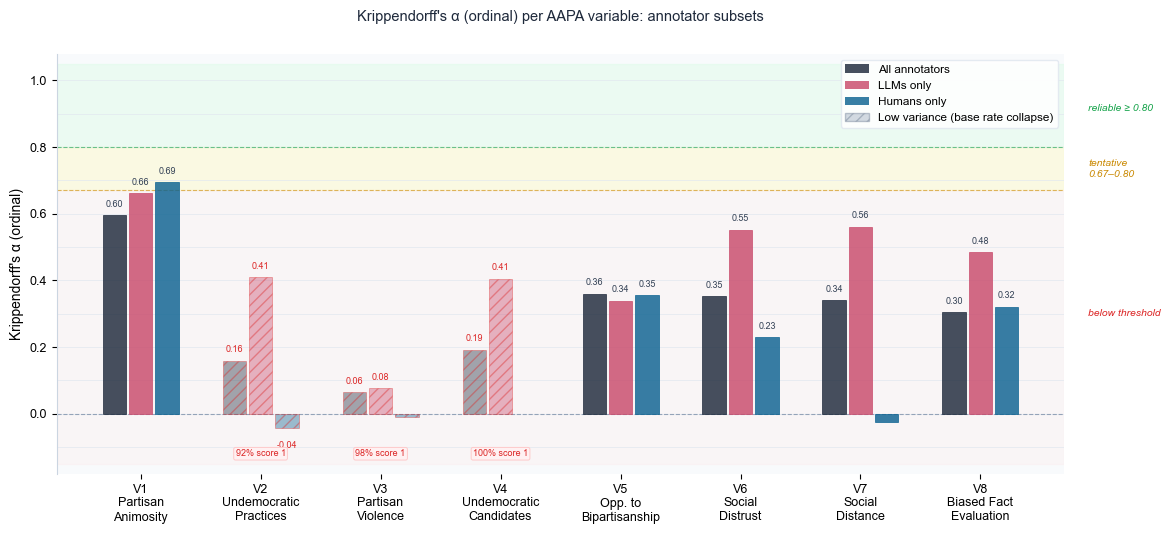

  Saved: study1/figures/fig1_krippendorff_barchart.png


In [47]:
DOT_SETS = {
    "All annotators": list(annotators.values()),
    "LLMs only":      list(llm_mats.values()),
    "Humans only":    [h1_mat, h2_mat],
}
DOT_COLOURS = {
    "All annotators": "#1E293B",
    "LLMs only":      "#C94A6B",
    "Humans only":    "#0C6291",
}

alpha_vals = {}
for aset, matrices in DOT_SETS.items():
    matrices = [m for m in matrices if m is not None]
    alpha_vals[aset] = {v: krippendorff_alpha(matrices, v) for v in SCORE_COLS}

n_sets = len(DOT_SETS)
bar_w  = 0.22
x      = np.arange(len(SCORE_COLS))

fig, ax = plt.subplots(figsize=(13, 6))
ax.set_facecolor("#F8FAFC")
fig.patch.set_facecolor("white")

ax.axhspan(THRESHOLD_HIGH, 1.05,          color="#DCFCE7", alpha=0.45, zorder=0)
ax.axhspan(THRESHOLD_LOW, THRESHOLD_HIGH, color="#FEF9C3", alpha=0.45, zorder=0)
ax.axhspan(-0.15, THRESHOLD_LOW,          color="#FEE2E2", alpha=0.2,  zorder=0)
ax.axhline(0, color="#94A3B8", linewidth=0.8, linestyle="--", zorder=1)
for y in np.arange(-0.1, 1.05, 0.1):
    ax.axhline(y, color="#E2E8F0", linewidth=0.5, zorder=0)

for si, (aset, colour) in enumerate(DOT_COLOURS.items()):
    offsets = x + (si - 1) * bar_w
    for xi, v in enumerate(SCORE_COLS):
        val   = alpha_vals[aset][v]
        is_lv = v in LOW_VARIANCE
        if np.isnan(val):
            continue
        ax.bar(offsets[xi], val, width=bar_w * 0.88, color=colour,
               alpha=0.4 if is_lv else 0.82,
               hatch="///" if is_lv else "",
               edgecolor="#DC2626" if is_lv else colour,
               linewidth=0.6, zorder=2,
               label=aset if xi == 0 else "")
        if abs(val) > 0.03:
            label_y = val + 0.02 if val >= 0 else val - 0.04
            ax.text(offsets[xi], label_y, f"{val:.2f}", fontsize=6.5,
                    ha="center", va="bottom" if val >= 0 else "top",
                    color="#DC2626" if is_lv else "#334155")

ax.text(len(SCORE_COLS) - 0.1, 0.915, "reliable ≥ 0.80",
        fontsize=7.5, color="#16A34A", va="center", style="italic")
ax.text(len(SCORE_COLS) - 0.1, 0.735, "tentative\n0.67–0.80",
        fontsize=7.5, color="#CA8A04", va="center", style="italic")
ax.text(len(SCORE_COLS) - 0.1, 0.30,  "below threshold",
        fontsize=7.5, color="#DC2626", va="center", style="italic")
ax.axhline(THRESHOLD_LOW,  color="#CA8A04", linewidth=0.8, linestyle="--", zorder=1, alpha=0.6)
ax.axhline(THRESHOLD_HIGH, color="#16A34A", linewidth=0.8, linestyle="--", zorder=1, alpha=0.6)

for xi, v in enumerate(SCORE_COLS):
    if v in LOW_VARIANCE:
        ax.text(x[xi], -0.12, BASE_RATE_LABEL[v], fontsize=6.5,
                color="#DC2626", ha="center", va="center",
                bbox=dict(boxstyle="round,pad=0.2", facecolor="#FFF1F2",
                          edgecolor="#FECACA", linewidth=0.7))

ax.set_xticks(x)
ax.set_xticklabels([VARIABLE_LABELS[v] for v in SCORE_COLS],
                   fontsize=8, multialignment="center")
ax.set_ylim(-0.18, 1.08)
ax.set_ylabel("Krippendorff's α (ordinal)", fontsize=10)
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
style_axes(ax)

legend_handles = [
    mpatches.Patch(facecolor=DOT_COLOURS[a], alpha=0.82, label=a) for a in DOT_SETS
]
legend_handles.append(
    mpatches.Patch(facecolor="#94A3B8", alpha=0.4, hatch="///",
                   edgecolor="#64748B", label="Low variance (base rate collapse)")
)
ax.legend(handles=legend_handles, fontsize=8.5, loc="upper right",
          framealpha=0.9, edgecolor="#E2E8F0")
ax.set_title("Krippendorff's α (ordinal) per AAPA variable: annotator subsets\n",
             fontsize=10.5, pad=12, color="#1E293B")
plt.subplots_adjust(bottom=0.18)
save_fig(fig, "fig1_krippendorff_barchart")

### Figure 2a: Agreement Matrix; Cohen's κ (Linear-Weighted) (obsolete)

In [32]:
# annotator×annotator matrix
def build_agreement_matrix(variable, metric, source_df):
    mat = pd.DataFrame(np.nan, index=ANNOTATOR_ORDER, columns=ANNOTATOR_ORDER)
    for a in ANNOTATOR_ORDER:
        mat.loc[a, a] = 1.0
    for _, row in source_df[source_df["variable"] == variable].iterrows():
        a, b = row["annotator_A"], row["annotator_B"]
        if a in ANNOTATOR_ORDER and b in ANNOTATOR_ORDER:
            mat.loc[a, b] = row[metric]
            mat.loc[b, a] = row[metric]
    return mat


def plot_agreement_matrices(metric, metric_label, stem, source_df, cmap_normal="Blues"):
    for v in SCORE_COLS:
        is_lv = v in LOW_VARIANCE
        mat   = build_agreement_matrix(v, metric, source_df)
        mask  = np.triu(np.ones_like(mat.values, dtype=bool), k=1)

        arr        = mat.copy().astype(float).values.copy()
        arr[mask]  = np.nan
        mat_masked = pd.DataFrame(arr, index=mat.index, columns=mat.columns)

        fig, ax = plt.subplots(figsize=(7, 6))
        ax.set_facecolor("#F8FAFC")
        fig.patch.set_facecolor("white")

        sns.heatmap(
            mat_masked, ax=ax,
            cmap=cmap_normal,
            vmin=0, vmax=1,
            linewidths=0.8, linecolor="white",
            annot=True, fmt=".2f", annot_kws={"size": 11},
            cbar_kws={"label": metric_label, "shrink": 0.8},
            mask=mask,
        )
        ax.set_title(
            f"{VARIABLE_LABELS[v].replace(chr(10), ': ')}",
            fontsize=11, fontweight="bold", pad=10,
            color="#DC2626" if is_lv else "#1E293B"
        )
        ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=9)
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
        ax.set_xlabel("")
        ax.set_ylabel("")
        plt.tight_layout()
        save_fig(fig, f"{stem}_{v.lower()}")


# plot_agreement_matrices("kappa_linear", "Linear-weighted κ",
#                         "fig2a_kappa", inter_df, cmap_normal="Blues")

### Figure 2b: Agreement Matrix; Spearman ρ

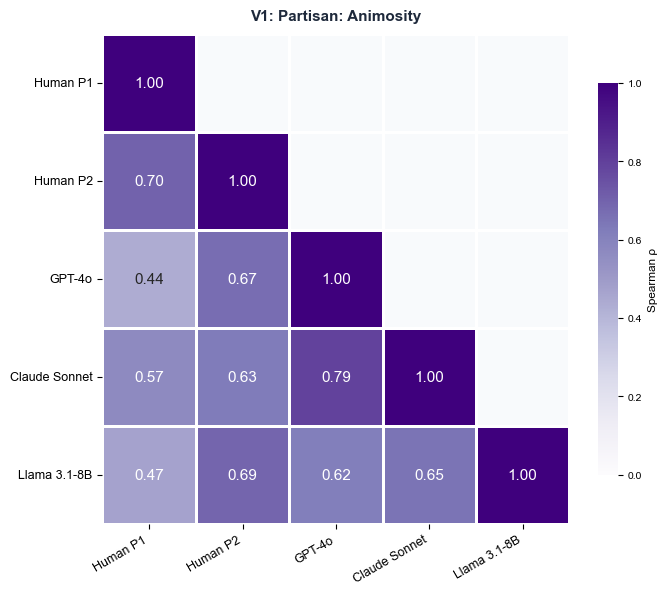

  Saved: study1/figures/fig2b_spearman_v1.png


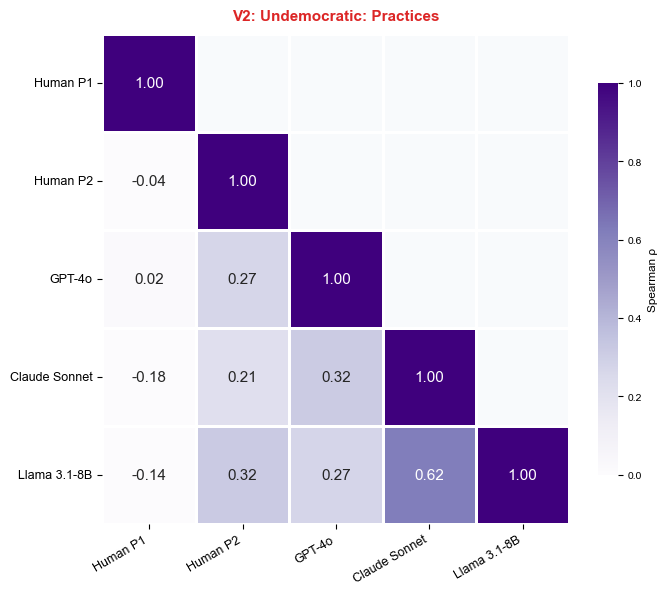

  Saved: study1/figures/fig2b_spearman_v2.png


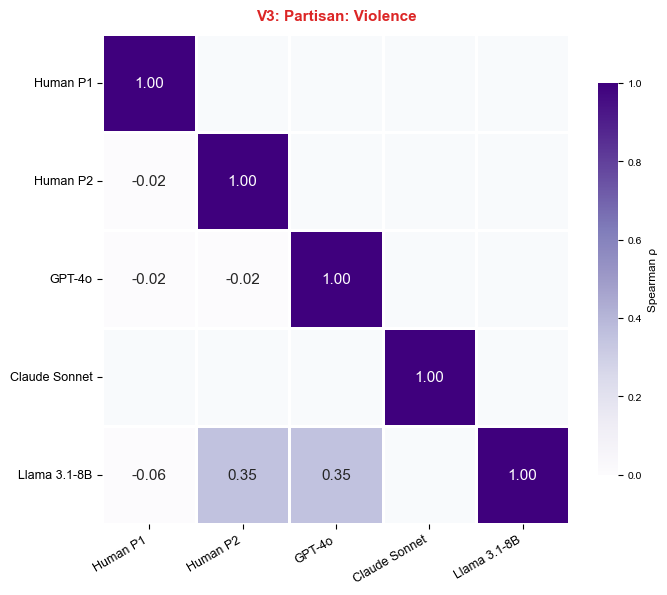

  Saved: study1/figures/fig2b_spearman_v3.png


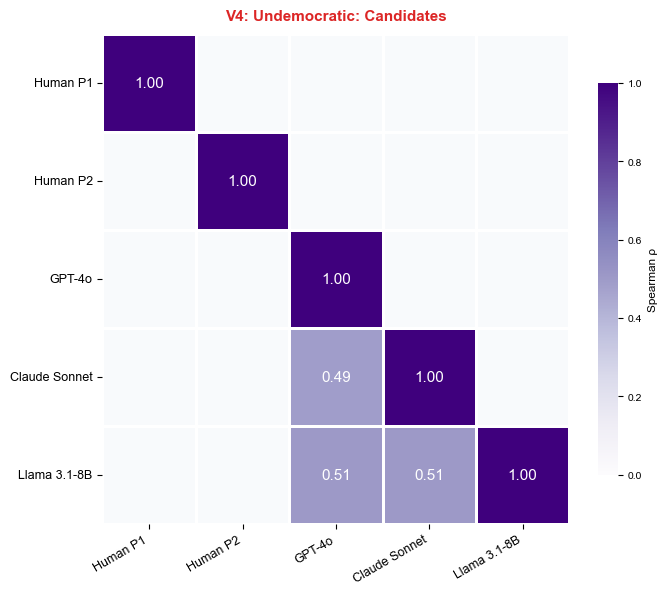

  Saved: study1/figures/fig2b_spearman_v4.png


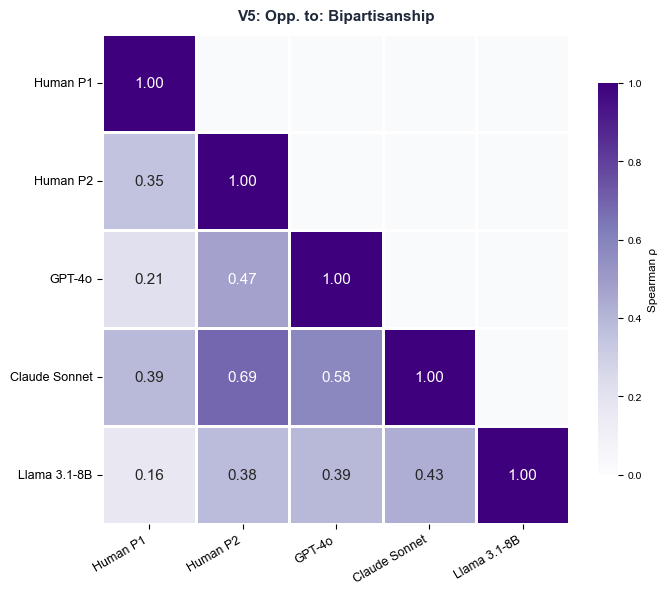

  Saved: study1/figures/fig2b_spearman_v5.png


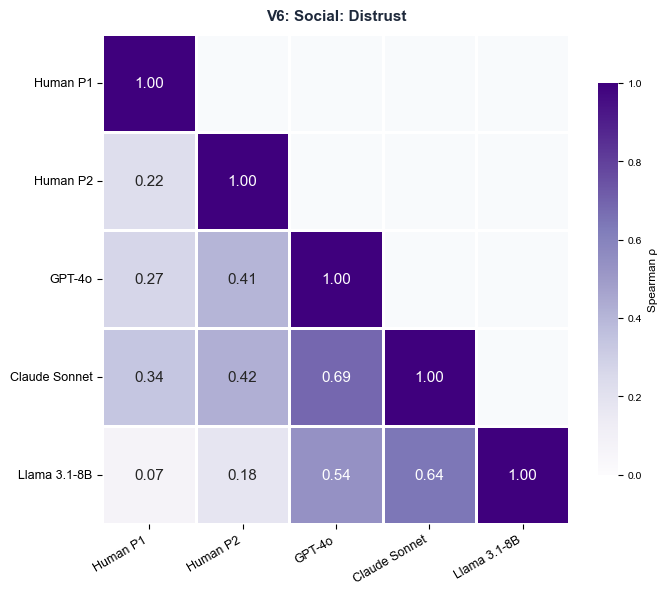

  Saved: study1/figures/fig2b_spearman_v6.png


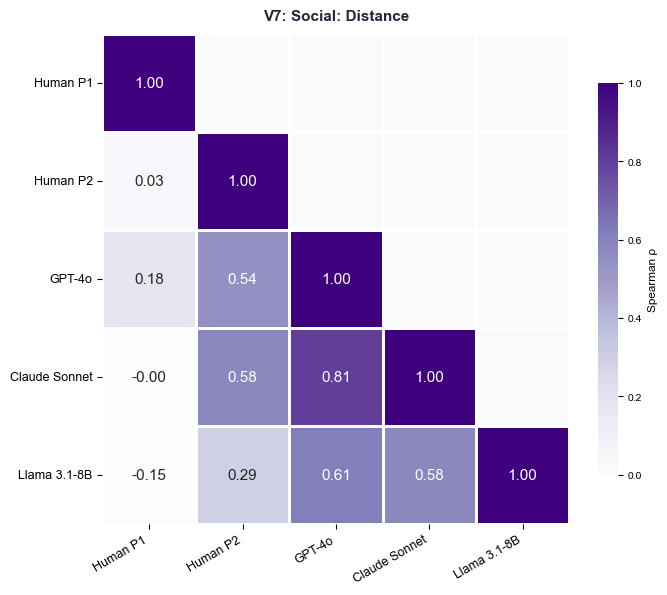

  Saved: study1/figures/fig2b_spearman_v7.png


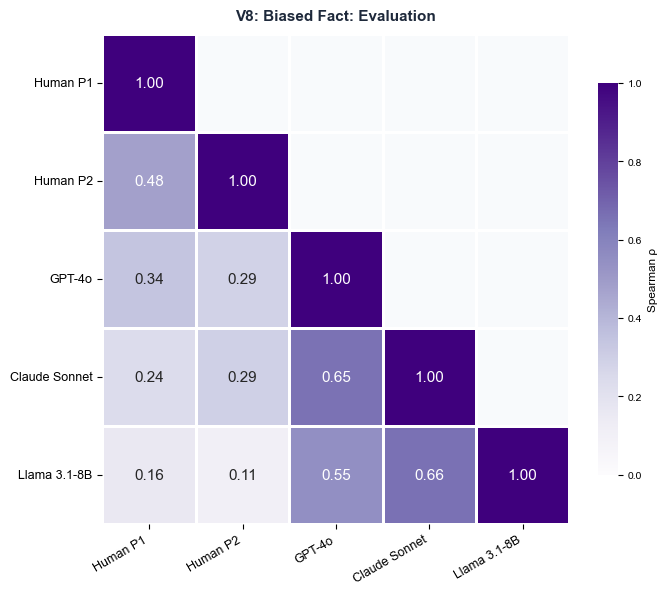

  Saved: study1/figures/fig2b_spearman_v8.png


In [33]:
plot_agreement_matrices("spearman_rho", "Spearman ρ",
                        "fig2b_spearman", inter_df, cmap_normal="Purples")

### Figure 2c: Agreement Matrix; Krippendorff's α (Pairwise)

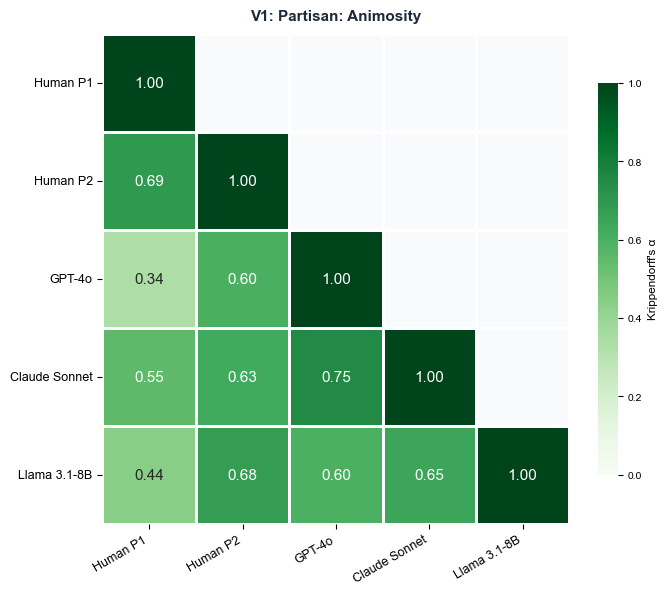

  Saved: study1/figures/fig2c_krippendorff_v1.png


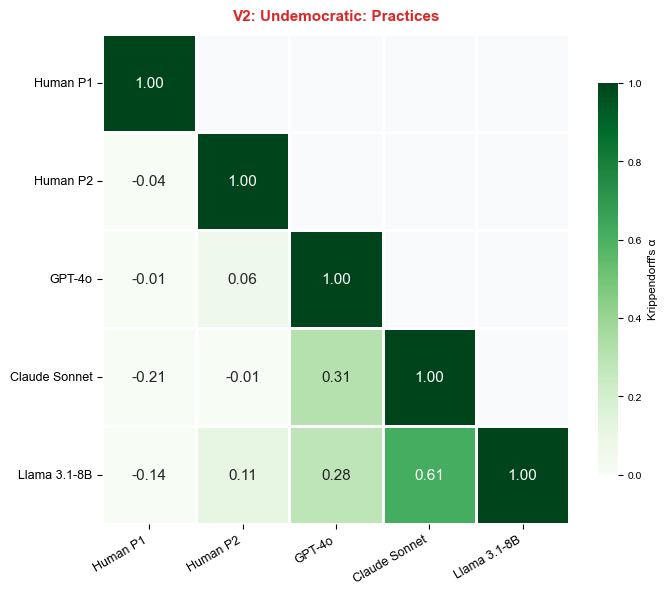

  Saved: study1/figures/fig2c_krippendorff_v2.png


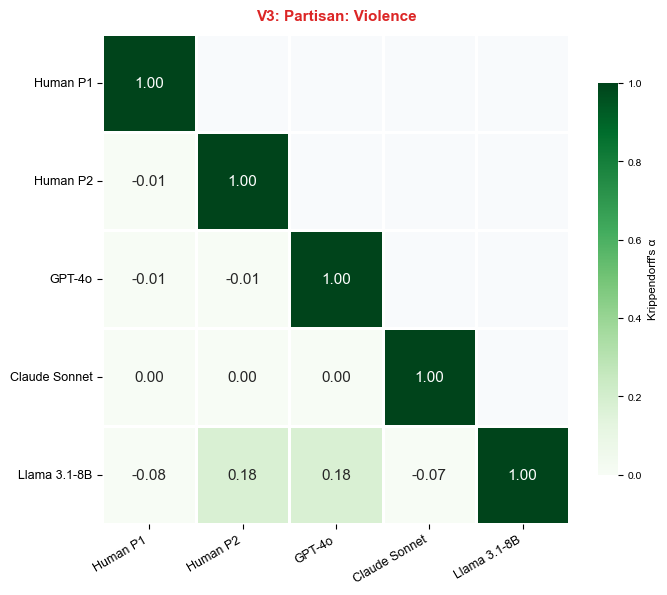

  Saved: study1/figures/fig2c_krippendorff_v3.png


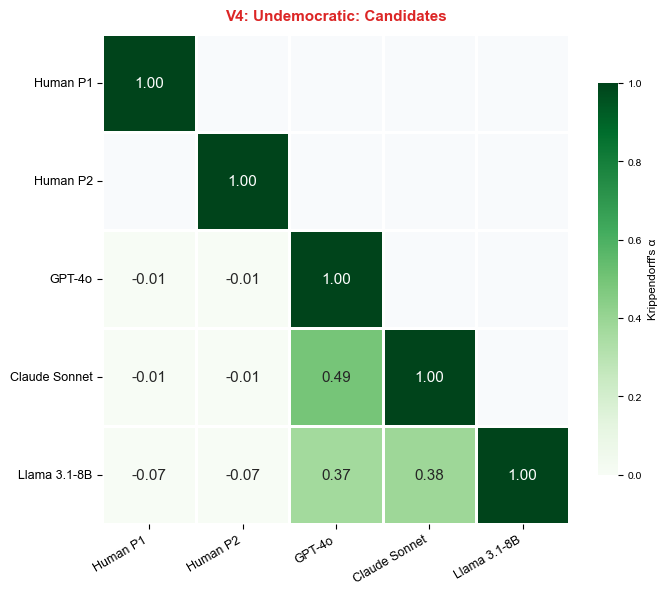

  Saved: study1/figures/fig2c_krippendorff_v4.png


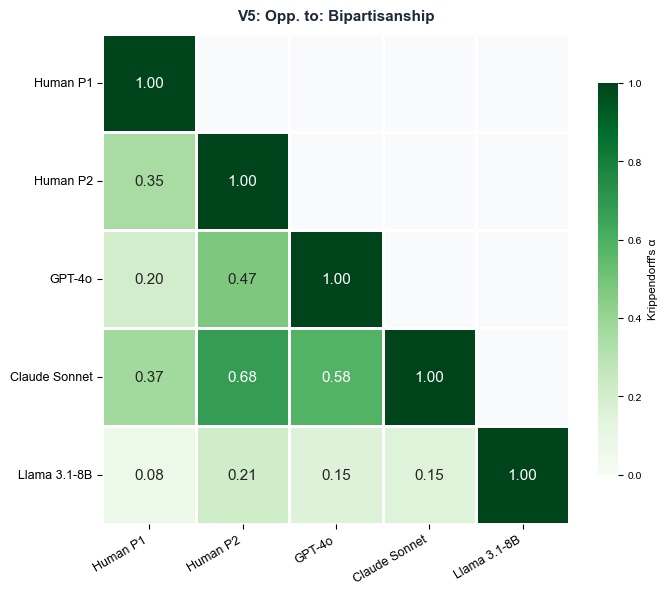

  Saved: study1/figures/fig2c_krippendorff_v5.png


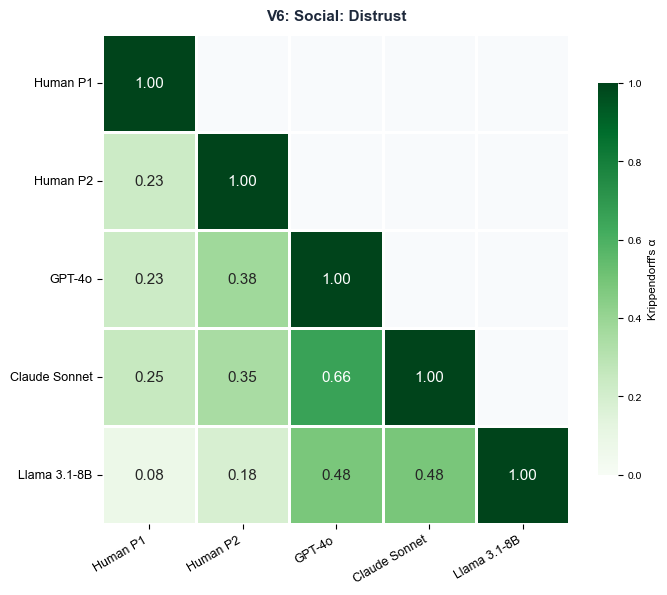

  Saved: study1/figures/fig2c_krippendorff_v6.png


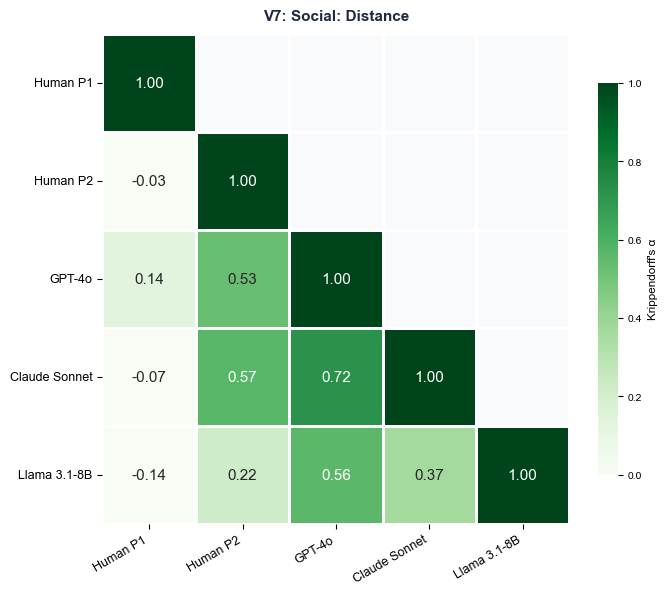

  Saved: study1/figures/fig2c_krippendorff_v7.png


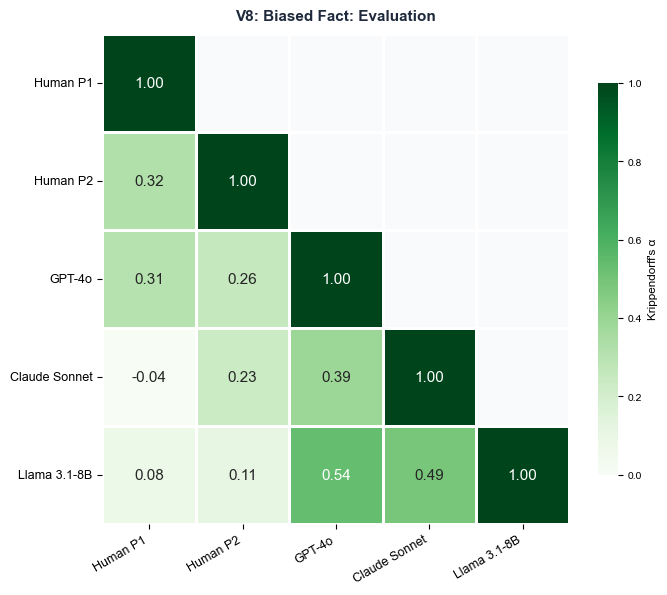

  Saved: study1/figures/fig2c_krippendorff_v8.png


In [34]:
# Reshape pairwise alpha rows into annotator_A / annotator_B long format
PAIR_ROWS = [
    "H1 + GPT-4o", "H1 + Claude Sonnet", "H1 + Llama 3.1-8B",
    "H2 + GPT-4o", "H2 + Claude Sonnet", "H2 + Llama 3.1-8B",
    "GPT-4o + Claude Sonnet", "GPT-4o + Llama 3.1-8B", "Claude Sonnet + Llama 3.1-8B",
]

# Also add H1 vs H2 row using human labels
PAIR_ROWS_FULL = ["Humans only (H1, H2)"] + PAIR_ROWS

alpha_pairs = (
    alpha_df.reset_index()
    [alpha_df.reset_index()["annotator_set"].isin(PAIR_ROWS)]
    .copy()
    .reset_index(drop=True)
)

alpha_pairs[["annotator_A", "annotator_B"]] = (
    alpha_pairs["annotator_set"].str.split(r"\s*\+\s*", n=1, expand=True)
)

# Normalise H1/H2 labels to match ANNOTATOR_ORDER
label_map = {"H1": "Human P1", "H2": "Human P2"}
alpha_pairs["annotator_A"] = alpha_pairs["annotator_A"].replace(label_map)
alpha_pairs["annotator_B"] = alpha_pairs["annotator_B"].replace(label_map)

# Add H1 vs H2 row
h1h2_row = alpha_df.loc[["Humans only (H1, H2)"]].reset_index()
h1h2_row["annotator_A"] = "Human P1"
h1h2_row["annotator_B"] = "Human P2"
alpha_pairs = pd.concat([alpha_pairs, h1h2_row], ignore_index=True)

# Melt to long
alpha_long = alpha_pairs.melt(
    id_vars=["annotator_A", "annotator_B"],
    value_vars=SCORE_COLS,
    var_name="variable",
    value_name="krippendorff_alpha",
)

plot_agreement_matrices("krippendorff_alpha", "Krippendorff's α",
                        "fig2c_krippendorff", alpha_long, cmap_normal="Greens")

### Figure 3: Score Drift Strip Plot

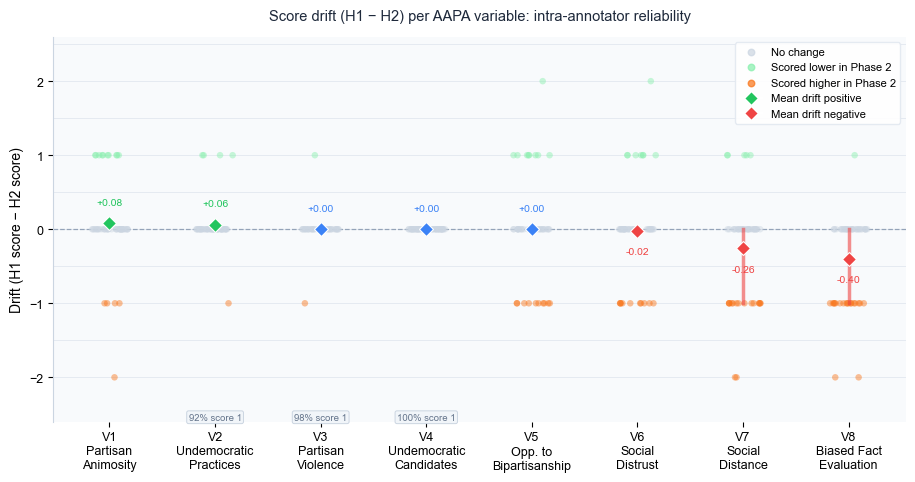

  Saved: study1/figures/fig3_drift_plot.png


In [49]:
drift_df     = pd.read_csv(os.path.join(OUTPUT_DIR, "score_drift.csv"))
drift_melted = (
    drift_df[[f"{v}_drift" for v in SCORE_COLS]]
    .rename(columns={f"{v}_drift": v for v in SCORE_COLS})
    .melt(var_name="variable", value_name="drift")
)

COLOUR_SAME = "#CBD5E1"
COLOUR_POS  = "#86EFAC"
COLOUR_NEG  = "#F97316"

fig, ax = plt.subplots(figsize=(11, 5))
ax.set_facecolor("#F8FAFC")
fig.patch.set_facecolor("white")

for y in np.arange(-2, 3, 0.5):
    ax.axhline(y, color="#E2E8F0", linewidth=0.6, zorder=0)
ax.axhline(0, color="#94A3B8", linewidth=0.9, linestyle="--", zorder=1)

rng = np.random.default_rng(42)
for xi, v in enumerate(SCORE_COLS):
    vals   = drift_melted[drift_melted["variable"] == v]["drift"].values
    jitter = rng.uniform(-0.18, 0.18, size=len(vals))
    dot_colours = [
        COLOUR_POS if d > 0 else COLOUR_NEG if d < 0 else COLOUR_SAME for d in vals
    ]
    ax.scatter(xi + jitter, vals, color=dot_colours, alpha=0.45, s=22, zorder=3, linewidths=0)

    mean_val    = vals.mean()
    mean_colour = "#22C55E" if mean_val > 0.01 else "#EF4444" if mean_val < -0.01 else "#3B82F6"
    ax.plot(xi, mean_val, marker="D", markersize=7, color=mean_colour, zorder=5,
            markeredgecolor="white", markeredgewidth=0.8)
    q25, q75 = np.percentile(vals, [25, 75])
    ax.plot([xi, xi], [q25, q75], color=mean_colour, linewidth=2.5, alpha=0.6, zorder=4)
    offset = 0.22 if mean_val >= 0 else -0.22
    ax.text(xi, mean_val + offset, f"{mean_val:+.2f}", fontsize=7.5,
            ha="center", va="bottom" if mean_val >= 0 else "top",
            color=mean_colour, fontweight="500")

ax.set_xticks(np.arange(len(SCORE_COLS)))
ax.set_xticklabels([VARIABLE_LABELS[v] for v in SCORE_COLS],
                   fontsize=7, rotation=0, ha="center", multialignment="center")
ax.set_ylabel("Drift (H1 score − H2 score)", fontsize=10)
ax.set_ylim(-2.6, 2.6)
ax.yaxis.set_major_locator(mticker.MultipleLocator(1))
style_axes(ax)

for xi, v in enumerate(SCORE_COLS):
    if v in LOW_VARIANCE:
        ax.annotate(BASE_RATE_LABEL[v], xy=(xi, -2.6), xycoords="data",
                    fontsize=6.8, color="#64748B", ha="center", va="bottom",
                    bbox=dict(boxstyle="round,pad=0.2", facecolor="#F1F5F9",
                              edgecolor="#CBD5E1", linewidth=0.7))

legend_handles = [
    plt.scatter([], [], color=COLOUR_SAME, alpha=0.7, s=22, label="No change"),
    plt.scatter([], [], color=COLOUR_POS,  alpha=0.7, s=22, label="Scored lower in Phase 2"),
    plt.scatter([], [], color=COLOUR_NEG,  alpha=0.7, s=22, label="Scored higher in Phase 2"),
    plt.Line2D([0], [0], marker="D", color="w", markerfacecolor="#22C55E",
               markersize=7, label="Mean drift positive"),
    plt.Line2D([0], [0], marker="D", color="w", markerfacecolor="#EF4444",
               markersize=7, label="Mean drift negative"),
]
ax.legend(handles=legend_handles, fontsize=8, loc="upper right",
          framealpha=0.9, edgecolor="#E2E8F0")
ax.set_title("Score drift (H1 − H2) per AAPA variable: intra-annotator reliability",
             fontsize=10.5, pad=12, color="#1E293B")
save_fig(fig, "fig3_drift_plot")

### Figure 3a: Score-Level Agreement Bar Chart (H1 vs H2)

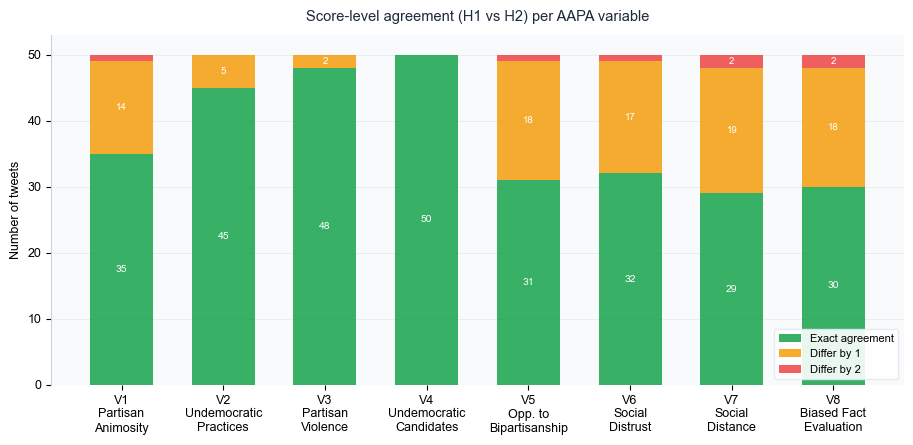

  Saved: study1/figures/fig3a_score_level_agreement.png


In [36]:
agree_exact = np.array([int(np.sum(np.abs(h1_mat[v].values - h2_mat[v].values) == 0)) for v in SCORE_COLS])
agree_one   = np.array([int(np.sum(np.abs(h1_mat[v].values - h2_mat[v].values) == 1)) for v in SCORE_COLS])
agree_two   = np.array([int(np.sum(np.abs(h1_mat[v].values - h2_mat[v].values) == 2)) for v in SCORE_COLS])
n_tweets    = len(h1_mat)
xi          = np.arange(len(SCORE_COLS))
bar_w       = 0.62

fig, ax = plt.subplots(figsize=(11, 5))
ax.set_facecolor("#F8FAFC")
fig.patch.set_facecolor("white")
for y in np.arange(0, n_tweets + 1, 10):
    ax.axhline(y, color="#E2E8F0", linewidth=0.5, zorder=0)

ax.bar(xi, agree_exact, width=bar_w, color="#16A34A", alpha=0.85, label="Exact agreement", zorder=2)
ax.bar(xi, agree_one,   width=bar_w, bottom=agree_exact, color="#F59E0B", alpha=0.85, label="Differ by 1", zorder=2)
ax.bar(xi, agree_two,   width=bar_w, bottom=agree_exact + agree_one, color="#EF4444", alpha=0.85, label="Differ by 2", zorder=2)

for i in range(len(SCORE_COLS)):
    ax.text(xi[i], agree_exact[i] / 2, str(agree_exact[i]),
            ha="center", va="center", fontsize=7.5, color="white", fontweight="500")
    if agree_one[i] >= 2:
        ax.text(xi[i], agree_exact[i] + agree_one[i] / 2, str(agree_one[i]),
                ha="center", va="center", fontsize=7, color="white", fontweight="500")
    if agree_two[i] >= 2:
        ax.text(xi[i], agree_exact[i] + agree_one[i] + agree_two[i] / 2, str(agree_two[i]),
                ha="center", va="center", fontsize=7, color="white", fontweight="500")

ax.set_xticks(xi)
ax.set_xticklabels([VARIABLE_LABELS[v] for v in SCORE_COLS], fontsize=7.5, multialignment="center")
ax.set_ylim(0, n_tweets + 3)
ax.yaxis.set_major_locator(mticker.MultipleLocator(10))
ax.set_ylabel("Number of tweets", fontsize=9)
ax.legend(loc="lower right", fontsize=8, framealpha=0.9, edgecolor="#E2E8F0")
style_axes(ax)
ax.set_title("Score-level agreement (H1 vs H2) per AAPA variable",
             fontsize=10.5, pad=10, color="#1E293B")
plt.subplots_adjust(bottom=0.18)
save_fig(fig, "fig3a_score_level_agreement")

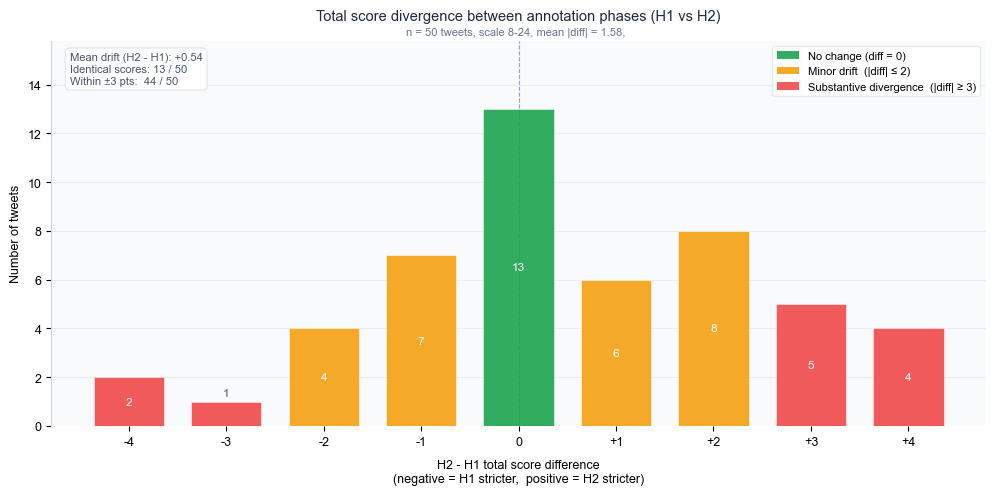

  Saved: study1/figures/fig3b_total_score_divergence_h1_h2.png


In [63]:
# ── Figure 3b: Total Score Divergence Histogram (H1 vs H2) ───────────────────
# Place after Figure 3a (score-level agreement bars).
# Uses h1_mat / h2_mat already built in Section 2, and the shared helpers
# style_axes / save_fig / VARIABLE_LABELS defined in Section 5.

# ── compute ───────────────────────────────────────────────────────────────────
h1_totals = h1_mat[SCORE_COLS].sum(axis=1)   # sum V1–V8; range 8–24
h2_totals = h2_mat[SCORE_COLS].sum(axis=1)

diff        = (h2_totals - h1_totals).values  # positive = H2 scored higher
n_valid     = len(diff)
mean_diff   = diff.mean()
mean_abs    = np.abs(diff).mean()
pct_within3 = 100 * (np.abs(diff) <= 3).mean()
n_identical = int((diff == 0).sum())

bins   = np.arange(-4, 6) - 0.5   # bin edges −4.5 … +4.5
xticks = np.arange(-4, 5)
counts, _ = np.histogram(diff, bins=bins)

def _bar_colour(x):
    if x == 0:       return "#16A34A"   # exact      → green
    if abs(x) <= 2:  return "#F59E0B"   # minor      → amber
    return "#EF4444"                     # substantive → red

colours = [_bar_colour(x) for x in xticks]

# ── figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_facecolor("#F8FAFC")
fig.patch.set_facecolor("white")

for y in range(0, int(counts.max()) + 3, 2):
    ax.axhline(y, color="#E2E8F0", linewidth=0.5, zorder=0)

bars = ax.bar(xticks, counts, width=0.72, color=colours,
              alpha=0.88, zorder=2, edgecolor="white", linewidth=0.4)

# count labels — inside bar if tall enough, above if not
for bar, count in zip(bars, counts):
    if count == 0:
        continue
    if bar.get_height() < 1.8:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.15, str(count),
                ha="center", va="bottom", fontsize=8.5,
                color="#475569", fontweight="500")
    else:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() / 2, str(count),
                ha="center", va="center", fontsize=8.5,
                color="white", fontweight="500")

# dashed zero line
ax.axvline(0, color="#94A3B8", linewidth=0.8, linestyle="--", zorder=1)

# axes
ax.set_xticks(xticks)
ax.set_xticklabels(
    [f"{x:+d}" if x != 0 else "0" for x in xticks], fontsize=9
)
ax.set_xlabel(
    "H2 - H1 total score difference\n"
    "(negative = H1 stricter,  positive = H2 stricter)",
    fontsize=9, labelpad=8
)
ax.set_ylabel("Number of tweets", fontsize=9)
ax.yaxis.set_major_locator(mticker.MultipleLocator(2))
ax.set_ylim(0, counts.max() + 2.8)

# title + subtitle
ax.set_title(
    "Total score divergence between annotation phases (H1 vs H2)",
    fontsize=10.5, pad=15, color="#1E293B"
)
ax.text(0.5, 1.01,
        f"n = {n_valid} tweets, scale 8-24, "
        f"mean |diff| = {mean_abs:.2f},  ",
        transform=ax.transAxes, ha="center", va="bottom",
        fontsize=8, color="#64748B")

# stat box
stats_text = (
    f"Mean drift (H2 - H1): {mean_diff:+.2f}\n"
    f"Identical scores: {n_identical} / {n_valid}\n"
    f"Within ±3 pts:  {int((np.abs(diff) <= 3).sum())} / {n_valid}"
)
ax.text(0.02, 0.97, stats_text,
        transform=ax.transAxes, va="top", ha="left", fontsize=8,
        color="#475569",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                  edgecolor="#E2E8F0", alpha=0.9))

# legend
legend_elements = [
    mpatches.Patch(facecolor="#16A34A", alpha=0.88, label="No change (diff = 0)"),
    mpatches.Patch(facecolor="#F59E0B", alpha=0.88, label="Minor drift  (|diff| ≤ 2)"),
    mpatches.Patch(facecolor="#EF4444", alpha=0.88, label="Substantive divergence  (|diff| ≥ 3)"),
]
ax.legend(handles=legend_elements, loc="upper right",
          fontsize=8, framealpha=0.9, edgecolor="#E2E8F0")

style_axes(ax)
plt.tight_layout()
save_fig(fig, "fig3b_total_score_divergence_h1_h2")

### Figure 3b: Connected Dot Plot; H1 vs H2 per Variable

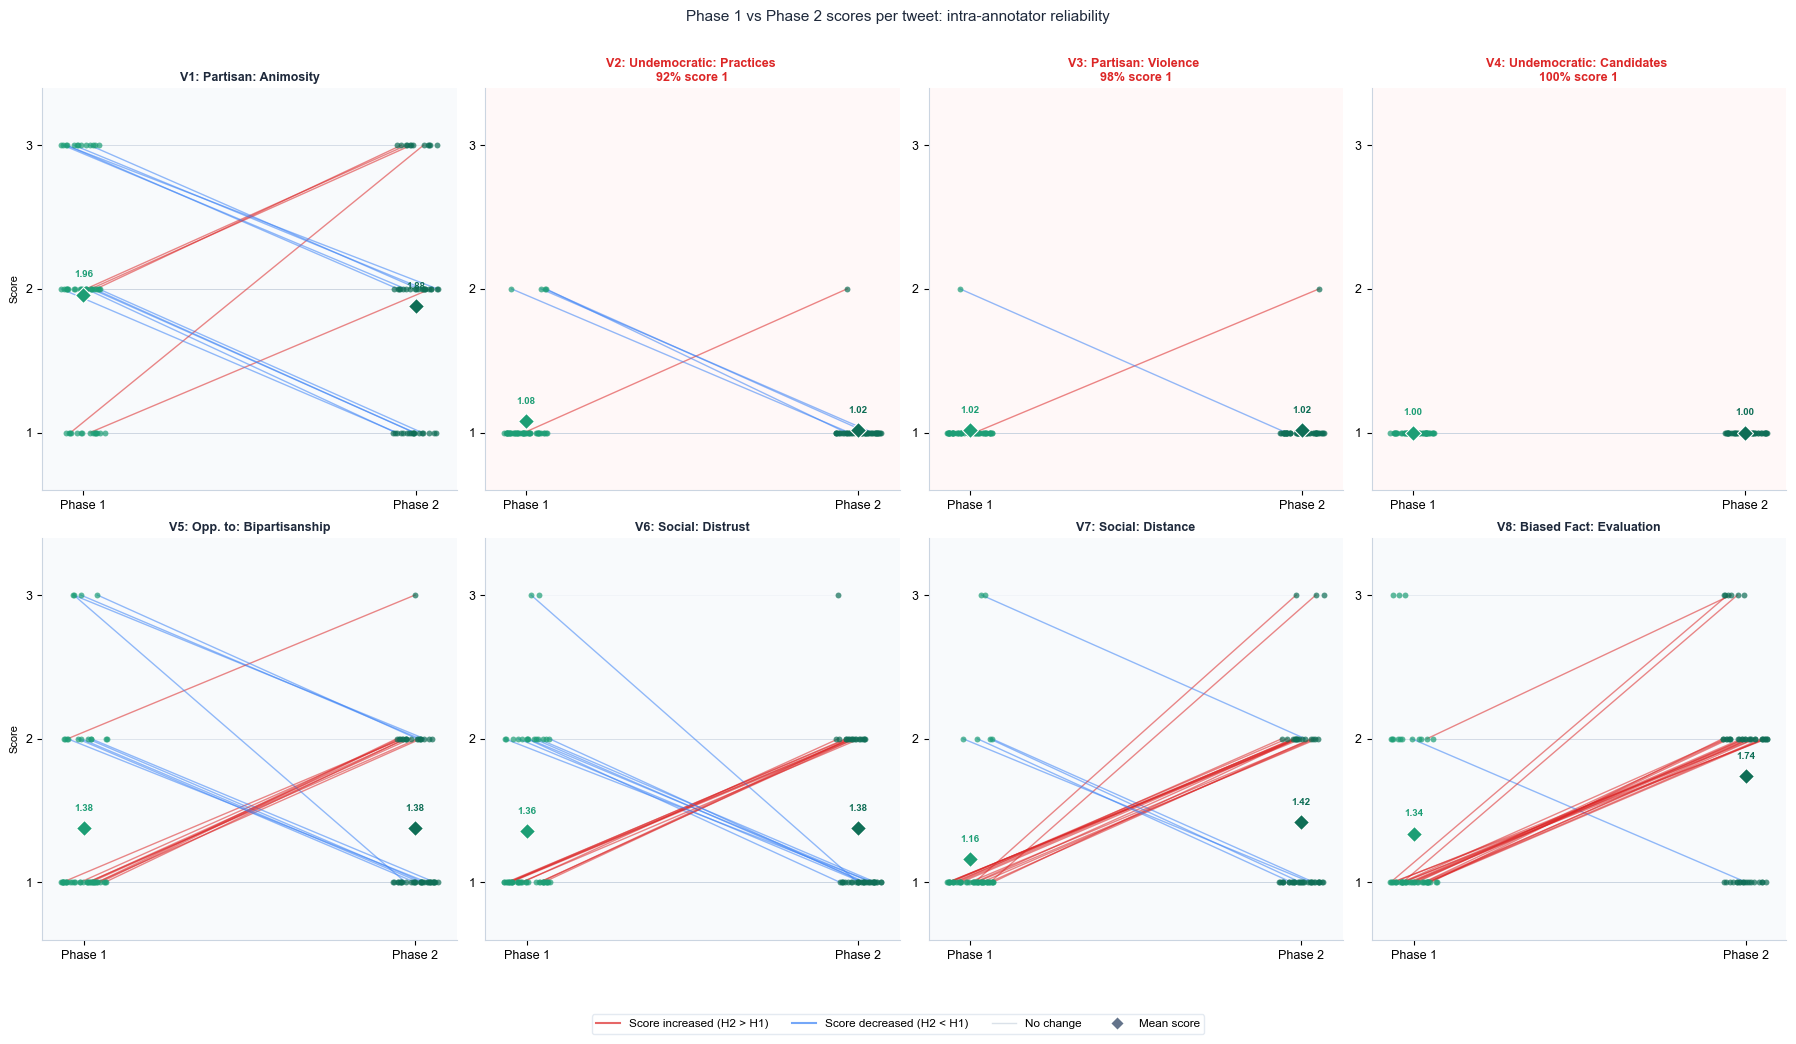

  Saved: study1/figures/fig3b_connected_dotplot.png


In [37]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()
fig.patch.set_facecolor("white")
rng = np.random.default_rng(42)

for i, v in enumerate(SCORE_COLS):
    ax    = axes[i]
    is_lv = v in LOW_VARIANCE
    ax.set_facecolor("#FFF8F8" if is_lv else "#F8FAFC")

    h1_scores = h1_mat[v].values
    h2_scores = h2_mat[v].values

    for h1_val, h2_val in zip(h1_scores, h2_scores):
        changed = h1_val != h2_val
        jitter_h1 = rng.uniform(-0.07, 0.07)
        jitter_h2 = rng.uniform(-0.07, 0.07)
        ax.plot([0 + jitter_h1, 1 + jitter_h2], [h1_val, h2_val],
                color="#DC2626" if h2_val > h1_val else "#3B82F6" if h2_val < h1_val else "#CBD5E1",
                alpha=0.55 if changed else 0.2,
                linewidth=1.0 if changed else 0.5, zorder=2 if changed else 1)
        ax.scatter(0 + jitter_h1, h1_val, color="#1D9E75", s=18, zorder=3, linewidths=0, alpha=0.7)
        ax.scatter(1 + jitter_h2, h2_val, color="#0F6E56", s=18, zorder=3, linewidths=0, alpha=0.7)

    ax.plot(0, np.mean(h1_scores), marker="D", markersize=8, color="#1D9E75",
            zorder=5, markeredgecolor="white", markeredgewidth=0.8)
    ax.plot(1, np.mean(h2_scores), marker="D", markersize=8, color="#0F6E56",
            zorder=5, markeredgecolor="white", markeredgewidth=0.8)
    ax.text(0, np.mean(h1_scores) + 0.12, f"{np.mean(h1_scores):.2f}",
            fontsize=7, ha="center", color="#1D9E75", fontweight="bold")
    ax.text(1, np.mean(h2_scores) + 0.12, f"{np.mean(h2_scores):.2f}",
            fontsize=7, ha="center", color="#0F6E56", fontweight="bold")

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Phase 1", "Phase 2"], fontsize=8.5)
    ax.set_yticks([1, 2, 3])
    ax.set_ylim(0.6, 3.4)
    ax.set_ylabel("Score" if i % 4 == 0 else "", fontsize=8)
    suffix = f" \n{BASE_RATE_LABEL[v]}" if is_lv else ""
    ax.set_title(f"{VARIABLE_LABELS[v].replace(chr(10), ': ')}{suffix}",
                 fontsize=9, fontweight="bold", pad=5,
                 color="#DC2626" if is_lv else "#1E293B")
    style_axes(ax)
    ax.spines["bottom"].set_visible(True)
    ax.spines["bottom"].set_color("#CBD5E1")

legend_handles = [
    plt.Line2D([0], [0], color="#DC2626", linewidth=1.5, alpha=0.7, label="Score increased (H2 > H1)"),
    plt.Line2D([0], [0], color="#3B82F6", linewidth=1.5, alpha=0.7, label="Score decreased (H2 < H1)"),
    plt.Line2D([0], [0], color="#CBD5E1", linewidth=1.0, alpha=0.7, label="No change"),
    plt.Line2D([0], [0], marker="D", color="w", markerfacecolor="#64748B",
               markersize=7, label="Mean score"),
]
fig.legend(handles=legend_handles, fontsize=8.5, loc="lower center", ncol=4,
           framealpha=0.9, edgecolor="#E2E8F0", bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Phase 1 vs Phase 2 scores per tweet: intra-annotator reliability",
             fontsize=11, y=1.01, color="#1E293B")
plt.tight_layout()
plt.subplots_adjust(bottom=0.08)
save_fig(fig, "fig3b_connected_dotplot")

### Figure 4: Score Distributions; All Annotators

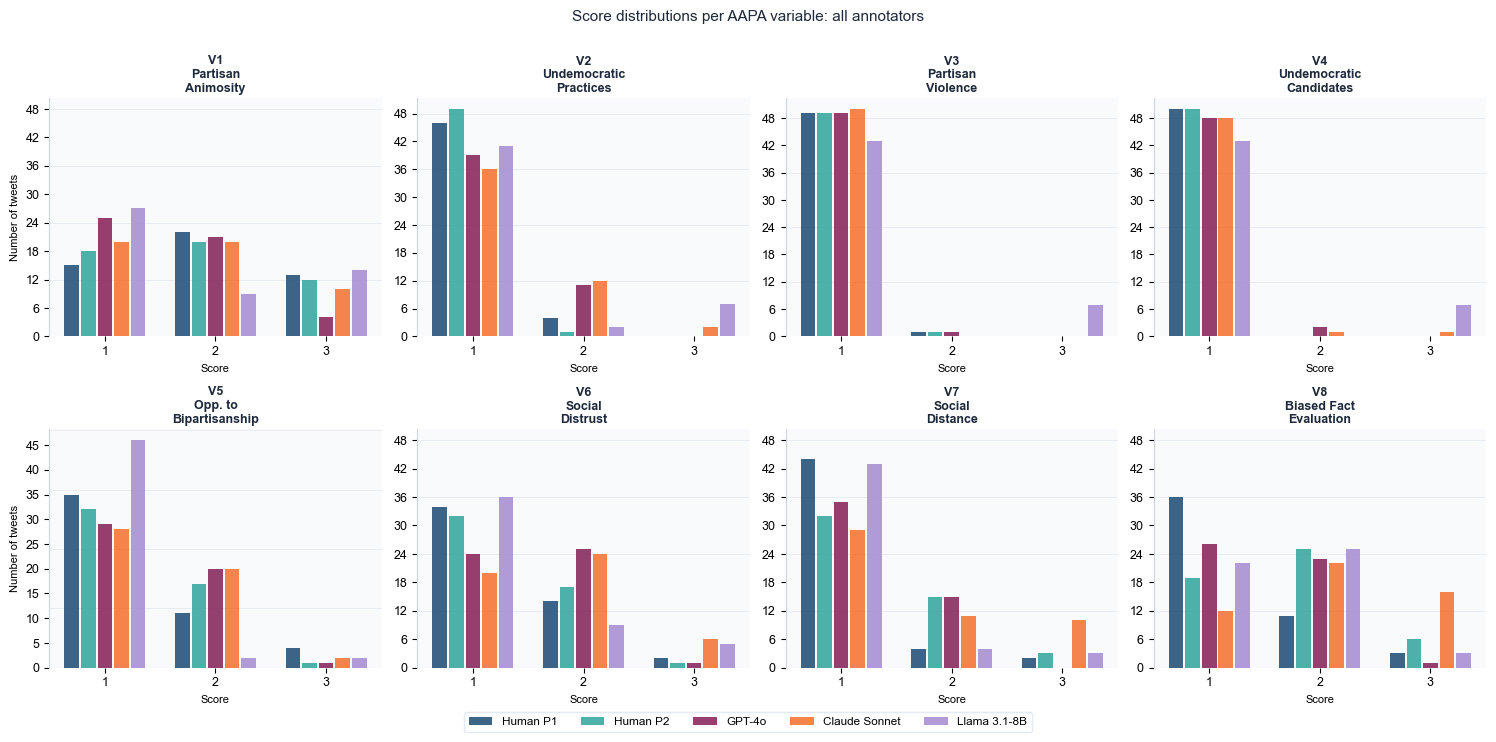

  Saved: study1/figures/fig4_score_distributions.png


In [46]:
fig, axes = plt.subplots(2, 4, figsize=(15, 7), sharey=False)
axes = axes.flatten()
fig.patch.set_facecolor("white")
bar_w = 0.75 / len(ANNOTATOR_ORDER)

for i, v in enumerate(SCORE_COLS):
    ax = axes[i]
    ax.set_facecolor("#F8FAFC")
    for j, label in enumerate(ANNOTATOR_ORDER):
        counts = (
            annotators[label][v]
            .value_counts()
            .reindex([1, 2, 3], fill_value=0)
        )
        offset = (j - len(ANNOTATOR_ORDER) / 2 + 0.5) * bar_w
        ax.bar(np.array([1, 2, 3]) + offset, counts.values,
               width=bar_w * 0.88, color=PALETTE[label], alpha=0.82,
               label=label if i == 0 else "", zorder=2)
    n_t = len(annotators[list(ANNOTATOR_ORDER)[0]][v])
    for y in np.arange(0, n_t + 1, max(1, n_t // 4)):
        ax.axhline(y, color="#E2E8F0", linewidth=0.5, zorder=0)
    ax.set_title(f"{VARIABLE_LABELS[v]}", fontsize=9, fontweight="bold",
                 pad=4, color="#1E293B")
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(["1", "2", "3"], fontsize=8)
    ax.set_xlabel("Score", fontsize=8)
    ax.set_ylabel("Number of tweets" if i % 4 == 0 else "", fontsize=8)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    style_axes(ax)

handles, labels_leg = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_leg, loc="lower center", ncol=len(ANNOTATOR_ORDER),
           fontsize=8.5, framealpha=0.9, edgecolor="#E2E8F0", bbox_to_anchor=(0.5, -0.03))
fig.suptitle("Score distributions per AAPA variable: all annotators",
             fontsize=11, y=1.01, color="#1E293B")
plt.tight_layout()
save_fig(fig, "fig4_score_distributions")

### Figure 5: Extreme Value Clustering

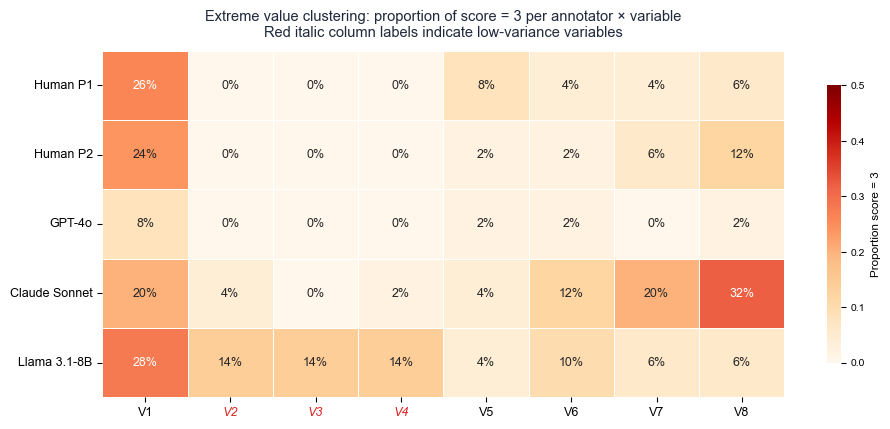

  Saved: study1/figures/fig5_extreme_value_clusters.png


In [39]:
extreme_pivot = (
    extreme_df
    .pivot_table(index="annotator", columns="variable", values="pct_score3")
    .reindex([a for a in ANNOTATOR_ORDER if a in extreme_df["annotator"].values])
)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.set_facecolor("#F8FAFC")
fig.patch.set_facecolor("white")

sns.heatmap(extreme_pivot, ax=ax, cmap="OrRd", vmin=0, vmax=0.5,
            linewidths=0.5, linecolor="white",
            annot=True, fmt=".0%", annot_kws={"size": 9},
            cbar_kws={"label": "Proportion score = 3", "shrink": 0.8})

for label in ax.get_xticklabels():
    if label.get_text() in LOW_VARIANCE:
        label.set_color("#DC2626")
        label.set_fontstyle("italic")

ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Extreme value clustering: proportion of score = 3 per annotator × variable\n"
             "Red italic column labels indicate low-variance variables",
             fontsize=10.5, pad=10, color="#1E293B")
save_fig(fig, "fig5_extreme_value_clusters")

---
## Run Summary

In [40]:
print("Study 1 analysis complete")
print(f"  CSVs:    ./{OUTPUT_DIR}/")
print(f"  Figures: ./{FIGURE_DIR}/")
print("\nOutputs:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    if f.endswith(".csv"):
        print(f"  {f}")
print("\nFigures:")
for f in sorted(os.listdir(FIGURE_DIR)):
    if f.endswith(".png"):
        print(f"  {f}")

Study 1 analysis complete
  CSVs:    ./study1/
  Figures: ./study1/figures/

Outputs:
  extreme_value_clusters.csv
  reliability_summary.csv
  representativeness_check.csv
  score_drift.csv
  sectionA_intra_annotator.csv
  sectionA_session_order.csv
  sectionB_inter_annotator.csv
  sectionC_krippendorff_alpha.csv

Figures:
  fig1_krippendorff_barchart.png
  fig1_krippendorff_dotplot.png
  fig2a_kappa_v1.png
  fig2a_kappa_v2.png
  fig2a_kappa_v3.png
  fig2a_kappa_v4.png
  fig2a_kappa_v5.png
  fig2a_kappa_v6.png
  fig2a_kappa_v7.png
  fig2a_kappa_v8.png
  fig2b_spearman_v1.png
  fig2b_spearman_v2.png
  fig2b_spearman_v3.png
  fig2b_spearman_v4.png
  fig2b_spearman_v5.png
  fig2b_spearman_v6.png
  fig2b_spearman_v7.png
  fig2b_spearman_v8.png
  fig2c_krippendorff_v1.png
  fig2c_krippendorff_v2.png
  fig2c_krippendorff_v3.png
  fig2c_krippendorff_v4.png
  fig2c_krippendorff_v5.png
  fig2c_krippendorff_v6.png
  fig2c_krippendorff_v7.png
  fig2c_krippendorff_v8.png
  fig3_drift_plot.png
  fi